# TP4 - Distribution-Aligned Sequence Distillation (DASD)
## Theme : Pokemon

Ce notebook implemente la methode DASD pour distiller les capacites de raisonnement d'un LLM enseignant (API Infomaniak) vers un modele etudiant compact (Qwen3-4B) via Llama-Factory.

**Pipeline :**
1. Generation d'un dataset Pokemon via l'API enseignant (2 stages de temperature)
2. Divergence-Aware Sampling (DAS) pour filtrer les donnees
3. Entrainement LoRA en 2 stages avec Llama-Factory
4. Evaluation du modele distille

---
## Phase 1 : Setup

In [ ]:
# Cellule 1 : Verification GPU
!nvidia-smi

Sat Feb 28 14:19:17 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   53C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
# Cellule 2 : Installation de Llama-Factory
!git clone --depth 1 https://github.com/hiyouga/LLaMA-Factory.git
%cd LLaMA-Factory
!pip install -e ".[torch,bitsandbytes]" -q
!llamafactory-cli version

Cloning into 'LLaMA-Factory'...
remote: Enumerating objects: 629, done.
remote: Counting objects: 100% (629/629), done.
remote: Compressing objects: 100% (469/469), done.
remote: Total 629 (delta 152), reused 414 (delta 102), pack-reused 0 (from 0)
Receiving objects: 100% (629/629), 5.25 MiB | 5.24 MiB/s, done.
Resolving deltas: 100% (152/152), done.
/content/LLaMA-Factory
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Installing backend dependencies ... done
  Preparing editable metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 375.8/375.8 kB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.5/40.5 MB 27.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 32.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.8/10

In [ ]:
# Cellule 3 : Imports et configuration
import json
import os
import time
import gc
import re
from pathlib import Path

import torch
import numpy as np
import matplotlib.pyplot as plt
import nltk
from openai import OpenAI
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

# Configuration API Infomaniak
from google.colab import userdata

API_KEY = userdata.get('INFOMANIAK_API_KEY')
BASE_URL = "https://api.infomaniak.com/2/ai/48/openai/v1"

client = OpenAI(api_key=API_KEY, base_url=BASE_URL)

# Repertoire de travail
WORK_DIR = Path("/content/LLaMA-Factory")
DATA_DIR = WORK_DIR / "data"

print(f"GPU disponible : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU : {torch.cuda.get_device_name(0)}")
    print(f"VRAM : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

GPU disponible : True
GPU : Tesla T4
VRAM : 15.6 GB


In [ ]:
# Cellule 4 : Listing des modeles disponibles sur l'API Infomaniak
models = client.models.list()
print("Modeles disponibles :")
for m in models.data:
    print(f"  - {m.id}")

# Modele enseignant : gpt-oss-120b (meme modele que le dataset de reference Alibaba DASD)
TEACHER_MODEL = "openai/gpt-oss-120b"
print(f"\nModele enseignant selectionne : {TEACHER_MODEL}")

AuthenticationError: Error code: 401 - {'error': {'message': 'Invalid Authentication', 'type': 'authentication_error', 'param': None, 'code': None}}

---
## Phase 2 : Etude du dataset de reference DASD

In [ ]:
# Cellule 5 : Etude du format du dataset de reference DASD
# Le dataset Alibaba a des problemes de compatibilite avec la lib datasets actuelle
# On documente directement le format attendu

print("="*60)
print("FORMAT DU DATASET DE REFERENCE DASD")
print("="*60)

print("""
Le dataset Alibaba-Apsara/Superior-Reasoning-SFT-gpt-oss-120b utilise :

Structure :
- input  : la question/instruction
- output : la reponse avec raisonnement structure
- domain : le domaine (math, code, general, etc.)
- meta   : metadonnees (temperature, modele teacher, etc.)

Format de raisonnement :
- Les reponses contiennent des balises <think>...</think>
- Le raisonnement structure apparait AVANT la reponse finale
- Exemple de structure :

<think>
Etape 1 : Analyser le probleme...
Etape 2 : Identifier les elements cles...
Etape 3 : Appliquer la methode...
</think>

La reponse finale est ici, apres le bloc think.

Pour notre TP Pokemon, nous utiliserons <reasoning>...</reasoning>
car c'est le format demande dans l'enonce.
""")

print("="*60)
print("On passe directement a la generation de notre dataset Pokemon.")
print("="*60)

FORMAT DU DATASET DE REFERENCE DASD

Le dataset Alibaba-Apsara/Superior-Reasoning-SFT-gpt-oss-120b utilise :

Structure :
- input  : la question/instruction
- output : la reponse avec raisonnement structure
- domain : le domaine (math, code, general, etc.)
- meta   : metadonnees (temperature, modele teacher, etc.)

Format de raisonnement :
- Les reponses contiennent des balises <think>...</think>
- Le raisonnement structure apparait AVANT la reponse finale
- Exemple de structure :

<think>
Etape 1 : Analyser le probleme...
Etape 2 : Identifier les elements cles...
Etape 3 : Appliquer la methode...
</think>

La reponse finale est ici, apres le bloc think.

Pour notre TP Pokemon, nous utiliserons <reasoning>...</reasoning>
car c'est le format demande dans l'enonce.

On passe directement a la generation de notre dataset Pokemon.


In [ ]:
# Cellule 6 : Resume du format de raisonnement pour notre TP

print("FORMAT QUE NOUS ALLONS UTILISER POUR LE TP POKEMON")
print("="*60)

print("""
System prompt pour le teacher :
  "Tu es un expert Pokemon competitif. Pour chaque question,
   raisonne etape par etape a l'interieur de balises
   <reasoning>...</reasoning> avant de donner ta reponse finale."

Exemple de reponse attendue :
---
<reasoning>
1. Dracaufeu est de type Feu/Vol
2. Le type Feu est faible contre Eau, Roche et Sol
3. Le type Vol ajoute une faiblesse Electrik et une double faiblesse Roche
4. En revanche, Vol annule la faiblesse Sol du type Feu
</reasoning>

Dracaufeu a donc 3 faiblesses : Eau (x2), Electrik (x2) et Roche (x4).
La double faiblesse Roche est particulierement dangereuse car les
Rochers Furtifs lui infligent 50% de degats a l'entree.
---

Ce format permet au modele etudiant d'apprendre :
- A structurer son raisonnement
- A separer reflexion et conclusion
- A etre methodique dans ses analyses
""")

print("\nPassons a la Phase 3 : Generation du dataset Pokemon !")

FORMAT QUE NOUS ALLONS UTILISER POUR LE TP POKEMON

System prompt pour le teacher :
  "Tu es un expert Pokemon competitif. Pour chaque question,
   raisonne etape par etape a l'interieur de balises
   <reasoning>...</reasoning> avant de donner ta reponse finale."

Exemple de reponse attendue :
---
<reasoning>
1. Dracaufeu est de type Feu/Vol
2. Le type Feu est faible contre Eau, Roche et Sol
3. Le type Vol ajoute une faiblesse Electrik et une double faiblesse Roche
4. En revanche, Vol annule la faiblesse Sol du type Feu
</reasoning>

Dracaufeu a donc 3 faiblesses : Eau (x2), Electrik (x2) et Roche (x4).
La double faiblesse Roche est particulierement dangereuse car les
Rochers Furtifs lui infligent 50% de degats a l'entree.
---

Ce format permet au modele etudiant d'apprendre :
- A structurer son raisonnement
- A separer reflexion et conclusion
- A etre methodique dans ses analyses


Passons a la Phase 3 : Generation du dataset Pokemon !


---
## Phase 3 : Generation du dataset Pokemon

In [ ]:
# Cellule 7 : Génération de 1000 questions Pokemon variées et riches
import random

# =============================================================================
# BASE DE DONNÉES POKEMON COMPLÈTE
# =============================================================================

# Pokémon avec leurs types (Gen 1-9 sélection représentative)
POKEMONS = {
    # Gen 1 - Starters et évolutions
    "Bulbizarre": ["Plante", "Poison"], "Herbizarre": ["Plante", "Poison"], "Florizarre": ["Plante", "Poison"],
    "Salamèche": ["Feu"], "Reptincel": ["Feu"], "Dracaufeu": ["Feu", "Vol"],
    "Carapuce": ["Eau"], "Carabaffe": ["Eau"], "Tortank": ["Eau"],
    # Gen 1 - Classiques
    "Pikachu": ["Electrik"], "Raichu": ["Electrik"], "Raichu d'Alola": ["Electrik", "Psy"],
    "Rondoudou": ["Normal", "Fée"], "Grodoudou": ["Normal", "Fée"],
    "Nosferapti": ["Poison", "Vol"], "Nosferalto": ["Poison", "Vol"], "Nostenfer": ["Poison", "Vol"],
    "Abra": ["Psy"], "Kadabra": ["Psy"], "Alakazam": ["Psy"],
    "Machoc": ["Combat"], "Machopeur": ["Combat"], "Mackogneur": ["Combat"],
    "Fantominus": ["Spectre", "Poison"], "Spectrum": ["Spectre", "Poison"], "Ectoplasma": ["Spectre", "Poison"],
    "Onix": ["Roche", "Sol"], "Steelix": ["Acier", "Sol"],
    "Insécateur": ["Insecte", "Vol"], "Cizayox": ["Insecte", "Acier"],
    "Elektek": ["Electrik"], "Elekable": ["Electrik"],
    "Magmar": ["Feu"], "Maganon": ["Feu"],
    "Magicarpe": ["Eau"], "Léviator": ["Eau", "Vol"],
    "Métamorph": ["Normal"],
    "Evoli": ["Normal"], "Aquali": ["Eau"], "Voltali": ["Electrik"], "Pyroli": ["Feu"],
    "Mentali": ["Psy"], "Noctali": ["Ténèbres"], "Phyllali": ["Plante"], "Givrali": ["Glace"], "Nymphali": ["Fée"],
    "Lokhlass": ["Eau", "Glace"],
    "Dracolosse": ["Dragon", "Vol"], "Minidraco": ["Dragon"], "Draco": ["Dragon"],
    "Mewtwo": ["Psy"], "Mew": ["Psy"],
    "Artikodin": ["Glace", "Vol"], "Électhor": ["Electrik", "Vol"], "Sulfura": ["Feu", "Vol"],
    "Ronflex": ["Normal"], "Scarabrute": ["Insecte"], "Tauros": ["Normal"],
    "Rhinocorne": ["Sol", "Roche"], "Rhinoféros": ["Sol", "Roche"], "Rhinastoc": ["Sol", "Roche"],
    "Leveinard": ["Normal"], "Leuphorie": ["Normal"],
    "Arcanin": ["Feu"], "Caninos": ["Feu"],
    "Grolem": ["Roche", "Sol"], "Grolem d'Alola": ["Roche", "Electrik"],
    "Hypnomade": ["Psy"], "Excelangue": ["Normal"], "Coudlangue": ["Normal"],

    # Gen 2
    "Germignon": ["Plante"], "Macronium": ["Plante"], "Méganium": ["Plante"],
    "Héricendre": ["Feu"], "Feurisson": ["Feu"], "Typhlosion": ["Feu"],
    "Kaiminus": ["Eau"], "Crocrodil": ["Eau"], "Aligatueur": ["Eau"],
    "Noctowl": ["Normal", "Vol"], "Coxyclaque": ["Insecte", "Vol"],
    "Pharamp": ["Electrik"], "Wattouat": ["Electrik"],
    "Joliflor": ["Plante"], "Granivol": ["Plante", "Vol"],
    "Scorplane": ["Sol", "Vol"], "Scorvol": ["Sol", "Vol"],
    "Qulbutoké": ["Psy"], "Zarbi": ["Psy"],
    "Feuforêve": ["Spectre"], "Magirêve": ["Spectre"],
    "Scarhino": ["Insecte", "Combat"],
    "Ursaring": ["Normal"], "Teddiursa": ["Normal"],
    "Démoloss": ["Ténèbres", "Feu"], "Malosse": ["Ténèbres", "Feu"],
    "Hyporoi": ["Eau", "Dragon"], "Hypocéan": ["Eau"],
    "Porygon2": ["Normal"], "Porygon-Z": ["Normal"],
    "Cerfrousse": ["Normal"], "Insolourdo": ["Normal"],
    "Tyranocif": ["Roche", "Ténèbres"], "Ymphect": ["Roche", "Ténèbres"],
    "Lugia": ["Psy", "Vol"], "Ho-Oh": ["Feu", "Vol"],
    "Celebi": ["Psy", "Plante"],
    "Raikou": ["Electrik"], "Entei": ["Feu"], "Suicune": ["Eau"],

    # Gen 3
    "Arcko": ["Plante"], "Massko": ["Plante"], "Jungko": ["Plante"],
    "Poussifeu": ["Feu"], "Galifeu": ["Feu", "Combat"], "Braségali": ["Feu", "Combat"],
    "Gobou": ["Eau"], "Flobio": ["Eau", "Sol"], "Laggron": ["Eau", "Sol"],
    "Gardevoir": ["Psy", "Fée"], "Gallame": ["Psy", "Combat"], "Kirlia": ["Psy", "Fée"],
    "Tengalice": ["Plante", "Ténèbres"], "Pifeuil": ["Plante", "Ténèbres"],
    "Hariyama": ["Combat"], "Makuhita": ["Combat"],
    "Mysdibule": ["Acier", "Fée"],
    "Ténéfix": ["Ténèbres", "Spectre"],
    "Charmina": ["Combat", "Psy"], "Méditikka": ["Combat", "Psy"],
    "Sharpedo": ["Eau", "Ténèbres"], "Carvanha": ["Eau", "Ténèbres"],
    "Wailord": ["Eau"], "Wailmer": ["Eau"],
    "Chamallot": ["Feu", "Sol"], "Camérupt": ["Feu", "Sol"],
    "Chartor": ["Feu"],
    "Libégon": ["Sol", "Dragon"], "Vibraninf": ["Sol", "Dragon"], "Kraknoix": ["Sol"],
    "Altaria": ["Dragon", "Vol"], "Tylton": ["Normal", "Vol"],
    "Mangriff": ["Normal"], "Séviper": ["Poison"],
    "Barpau": ["Eau"], "Milobellus": ["Eau"],
    "Absol": ["Ténèbres"],
    "Branette": ["Spectre"], "Polichombr": ["Spectre"],
    "Mélodelfe": ["Fée"], "Mélofée": ["Fée"],
    "Métalosse": ["Acier", "Psy"], "Métang": ["Acier", "Psy"], "Terhal": ["Acier", "Psy"],
    "Drattack": ["Dragon"], "Drattak": ["Dragon", "Vol"],
    "Latias": ["Dragon", "Psy"], "Latios": ["Dragon", "Psy"],
    "Kyogre": ["Eau"], "Groudon": ["Sol"], "Rayquaza": ["Dragon", "Vol"],
    "Jirachi": ["Acier", "Psy"], "Deoxys": ["Psy"],
    "Regirock": ["Roche"], "Regice": ["Glace"], "Registeel": ["Acier"],

    # Gen 4
    "Tortipouss": ["Plante"], "Boskara": ["Plante"], "Torterra": ["Plante", "Sol"],
    "Ouisticram": ["Feu"], "Chimpenfeu": ["Feu", "Combat"], "Simiabraz": ["Feu", "Combat"],
    "Tiplouf": ["Eau"], "Prinplouf": ["Eau"], "Pingoléon": ["Eau", "Acier"],
    "Etouraptor": ["Normal", "Vol"], "Etourvol": ["Normal", "Vol"],
    "Carchacrok": ["Dragon", "Sol"], "Carmache": ["Dragon", "Sol"], "Griknot": ["Dragon", "Sol"],
    "Lucario": ["Combat", "Acier"], "Riolu": ["Combat"],
    "Hippodocus": ["Sol"], "Hippopotas": ["Sol"],
    "Cradopaud": ["Poison", "Combat"], "Coatox": ["Poison", "Combat"],
    "Corboss": ["Ténèbres", "Vol"], "Cornebre": ["Ténèbres", "Vol"],
    "Moufouette": ["Poison", "Ténèbres"], "Moufflair": ["Poison", "Ténèbres"],
    "Goinfrex": ["Normal"], "Munchlax": ["Normal"],
    "Archeodong": ["Acier", "Psy"], "Archéomire": ["Acier", "Psy"],
    "Spiritomb": ["Spectre", "Ténèbres"],
    "Roserade": ["Plante", "Poison"], "Rosélia": ["Plante", "Poison"],
    "Momartik": ["Glace", "Spectre"], "Stalgamin": ["Glace"],
    "Dimoret": ["Ténèbres", "Glace"], "Farfuret": ["Ténèbres", "Glace"],
    "Togekiss": ["Fée", "Vol"], "Togetic": ["Fée", "Vol"], "Togepi": ["Fée"],
    "Maganon": ["Feu"], "Elekable": ["Electrik"],
    "Motisma": ["Electrik", "Spectre"],
    "Cresselia": ["Psy"], "Darkrai": ["Ténèbres"],
    "Dialga": ["Acier", "Dragon"], "Palkia": ["Eau", "Dragon"], "Giratina": ["Spectre", "Dragon"],
    "Heatran": ["Feu", "Acier"],
    "Regigigas": ["Normal"],
    "Arceus": ["Normal"],
    "Manaphy": ["Eau"], "Phione": ["Eau"],
    "Shaymin": ["Plante"],

    # Gen 5
    "Vipélierre": ["Plante"], "Lianaja": ["Plante"], "Majaspic": ["Plante"],
    "Gruikui": ["Feu"], "Grotichon": ["Feu", "Combat"], "Roitiflam": ["Feu", "Combat"],
    "Moustillon": ["Eau"], "Mateloutre": ["Eau"], "Clamiral": ["Eau"],
    "Gueriaigle": ["Normal", "Vol"],
    "Zoroark": ["Ténèbres"], "Zorua": ["Ténèbres"],
    "Tranchodon": ["Dragon"], "Incisache": ["Dragon"], "Coupenotte": ["Dragon"],
    "Minotaupe": ["Sol", "Acier"], "Rototaupe": ["Sol"],
    "Cryptéro": ["Psy", "Vol"],
    "Limonde": ["Sol", "Electrik"],
    "Mygavolt": ["Insecte", "Electrik"],
    "Brutalibre": ["Combat", "Vol"],
    "Tutafeh": ["Spectre"], "Tutankafer": ["Spectre"],
    "Escargaume": ["Insecte"], "Limaspeed": ["Insecte"],
    "Fermite": ["Insecte", "Acier"],
    "Cobaltium": ["Acier", "Combat"], "Terrakium": ["Roche", "Combat"], "Viridium": ["Plante", "Combat"],
    "Boréas": ["Vol"], "Fulguris": ["Electrik", "Vol"], "Démétéros": ["Sol", "Vol"],
    "Reshiram": ["Dragon", "Feu"], "Zekrom": ["Dragon", "Electrik"], "Kyurem": ["Dragon", "Glace"],
    "Keldeo": ["Eau", "Combat"],
    "Genesect": ["Insecte", "Acier"],
    "Méloetta": ["Normal", "Psy"],
    "Victini": ["Psy", "Feu"],

    # Gen 6
    "Marisson": ["Plante"], "Boguérisse": ["Plante"], "Blindépique": ["Plante", "Combat"],
    "Feunnec": ["Feu"], "Roussil": ["Feu"], "Goupelin": ["Feu", "Psy"],
    "Grenousse": ["Eau"], "Croâporal": ["Eau"], "Amphinobi": ["Eau", "Ténèbres"],
    "Sapereau": ["Normal"], "Excavarenne": ["Normal", "Sol"],
    "Flambusard": ["Feu", "Vol"], "Braisillon": ["Feu", "Vol"],
    "Prismillon": ["Insecte", "Vol"],
    "Flabébé": ["Fée"], "Floette": ["Fée"], "Florges": ["Fée"],
    "Dragmara": ["Poison", "Dragon"],
    "Brutalibré": ["Combat", "Vol"],
    "Sonistrelle": ["Vol", "Dragon"], "Bruyverne": ["Vol", "Dragon"],
    "Nymphali": ["Fée"],
    "Dedenne": ["Electrik", "Fée"],
    "Mucuscule": ["Dragon"], "Colimucus": ["Dragon"], "Muplodocus": ["Dragon"],
    "Couafarel": ["Normal"],
    "Trousselin": ["Acier", "Fée"],
    "Xerneas": ["Fée"], "Yveltal": ["Ténèbres", "Vol"], "Zygarde": ["Dragon", "Sol"],
    "Diancie": ["Roche", "Fée"], "Hoopa": ["Psy", "Spectre"], "Volcanion": ["Feu", "Eau"],

    # Gen 7
    "Brindibou": ["Plante", "Vol"], "Efflèche": ["Plante", "Vol"], "Archéduc": ["Plante", "Spectre"],
    "Flamiaou": ["Feu"], "Matoufeu": ["Feu"], "Félinferno": ["Feu", "Ténèbres"],
    "Otaquin": ["Eau"], "Otarlette": ["Eau"], "Oratoria": ["Eau", "Fée"],
    "Manglouton": ["Normal"], "Argouste": ["Normal"],
    "Bombydou": ["Insecte", "Fée"], "Rubombelle": ["Insecte", "Fée"],
    "Rocabot": ["Roche"], "Lougaroc": ["Roche"],
    "Froussardine": ["Eau"],
    "Mimiqui": ["Spectre", "Fée"],
    "Dodoala": ["Normal"],
    "Togedemaru": ["Electrik", "Acier"],
    "Draïeul": ["Normal", "Dragon"],
    "Silvallié": ["Normal"],
    "Cosmog": ["Psy"], "Cosmovum": ["Psy"], "Solgaleo": ["Psy", "Acier"], "Lunala": ["Psy", "Spectre"],
    "Necrozma": ["Psy"],
    "Tokopisco": ["Eau", "Fée"], "Tokorico": ["Electrik", "Fée"], "Tokopiyon": ["Psy", "Fée"], "Tokotoro": ["Plante", "Fée"],
    "Cosmovum": ["Psy"],
    "Zeraora": ["Electrik"],
    "Marshadow": ["Combat", "Spectre"],
    "Magearna": ["Acier", "Fée"],

    # Gen 8
    "Ouistempo": ["Plante"], "Badabouin": ["Plante"], "Gorythmic": ["Plante"],
    "Flambino": ["Feu"], "Lapyro": ["Feu"], "Pyrobut": ["Feu"],
    "Larméléon": ["Eau"], "Arrozard": ["Eau"], "Lézargus": ["Eau"],
    "Corvaillus": ["Vol", "Acier"],
    "Palarticho": ["Combat"],
    "Sorcilence": ["Psy"],
    "Pachyradjah": ["Sol"],
    "Nigosier": ["Vol", "Eau"],
    "Hexadron": ["Dragon", "Spectre"],
    "Duralugon": ["Acier", "Dragon"],
    "Zacian": ["Fée"], "Zamazenta": ["Combat"],
    "Éthernatos": ["Poison", "Dragon"],
    "Sylveroy": ["Psy", "Plante"],
    "Regieleki": ["Electrik"], "Regidrago": ["Dragon"],

    # Gen 9
    "Poussacha": ["Plante"], "Matourgeon": ["Plante"], "Miascarade": ["Plante", "Ténèbres"],
    "Chochodile": ["Feu"], "Crocogril": ["Feu"], "Flâmigator": ["Feu", "Spectre"],
    "Coiffeton": ["Eau"], "Canarbello": ["Eau"], "Palmaval": ["Eau"],
    "Pohm": ["Electrik"], "Pohmotte": ["Electrik", "Combat"], "Pohmarmotte": ["Electrik", "Combat"],
    "Tapatoès": ["Normal", "Vol"],
    "Chongjian": ["Ténèbres", "Plante"], "Baojian": ["Ténèbres", "Glace"],
    "Tinglu": ["Ténèbres", "Sol"], "Yuyu": ["Ténèbres", "Feu"],
    "Koraidon": ["Combat", "Dragon"], "Miraidon": ["Electrik", "Dragon"],
    "Serpente": ["Acier", "Dragon"],
}

# Tous les types
TYPES = ["Normal", "Feu", "Eau", "Plante", "Electrik", "Glace", "Combat", "Poison",
         "Sol", "Vol", "Psy", "Insecte", "Roche", "Spectre", "Dragon", "Ténèbres", "Acier", "Fée"]

# Attaques avec type et puissance
ATTAQUES = {
    # Feu
    "Lance-Flammes": {"type": "Feu", "puissance": 90, "categorie": "Spécial"},
    "Déflagration": {"type": "Feu", "puissance": 110, "categorie": "Spécial"},
    "Surchauffe": {"type": "Feu", "puissance": 130, "categorie": "Spécial"},
    "Boutefeu": {"type": "Feu", "puissance": 120, "categorie": "Physique"},
    "Flamme Ultime": {"type": "Feu", "puissance": 150, "categorie": "Spécial"},
    "Poing de Feu": {"type": "Feu", "puissance": 75, "categorie": "Physique"},
    "Roue de Feu": {"type": "Feu", "puissance": 60, "categorie": "Physique"},
    # Eau
    "Surf": {"type": "Eau", "puissance": 90, "categorie": "Spécial"},
    "Hydrocanon": {"type": "Eau", "puissance": 110, "categorie": "Spécial"},
    "Hydroqueue": {"type": "Eau", "puissance": 90, "categorie": "Physique"},
    "Cascade": {"type": "Eau", "puissance": 80, "categorie": "Physique"},
    "Ébullition": {"type": "Eau", "puissance": 80, "categorie": "Spécial"},
    "Aqua-Jet": {"type": "Eau", "puissance": 40, "categorie": "Physique"},
    "Ocroupi": {"type": "Eau", "puissance": 65, "categorie": "Spécial"},
    # Plante
    "Tempête Florale": {"type": "Plante", "puissance": 90, "categorie": "Spécial"},
    "Lance-Soleil": {"type": "Plante", "puissance": 120, "categorie": "Spécial"},
    "Végé-Attak": {"type": "Plante", "puissance": 150, "categorie": "Spécial"},
    "Lame-Feuille": {"type": "Plante", "puissance": 90, "categorie": "Physique"},
    "Martobois": {"type": "Plante", "puissance": 120, "categorie": "Physique"},
    "Fouet Lianes": {"type": "Plante", "puissance": 45, "categorie": "Physique"},
    # Electrik
    "Tonnerre": {"type": "Electrik", "puissance": 90, "categorie": "Spécial"},
    "Fatal-Foudre": {"type": "Electrik", "puissance": 110, "categorie": "Spécial"},
    "Éclair Fou": {"type": "Electrik", "puissance": 90, "categorie": "Physique"},
    "Coup d'Jus": {"type": "Electrik", "puissance": 80, "categorie": "Spécial"},
    "Électacle": {"type": "Electrik", "puissance": 120, "categorie": "Physique"},
    "Cage-Éclair": {"type": "Electrik", "puissance": 0, "categorie": "Statut"},
    # Glace
    "Laser Glace": {"type": "Glace", "puissance": 90, "categorie": "Spécial"},
    "Blizzard": {"type": "Glace", "puissance": 110, "categorie": "Spécial"},
    "Lyophilisation": {"type": "Glace", "puissance": 70, "categorie": "Spécial"},
    "Poinglace": {"type": "Glace", "puissance": 75, "categorie": "Physique"},
    "Éclats Glace": {"type": "Glace", "puissance": 40, "categorie": "Physique"},
    # Combat
    "Close Combat": {"type": "Combat", "puissance": 120, "categorie": "Physique"},
    "Aurasphère": {"type": "Combat", "puissance": 80, "categorie": "Spécial"},
    "Surpuissance": {"type": "Combat", "puissance": 120, "categorie": "Physique"},
    "Poing Boost": {"type": "Combat", "puissance": 40, "categorie": "Physique"},
    "Vampipoing": {"type": "Combat", "puissance": 75, "categorie": "Physique"},
    "Balayette": {"type": "Combat", "puissance": 60, "categorie": "Physique"},
    # Sol
    "Séisme": {"type": "Sol", "puissance": 100, "categorie": "Physique"},
    "Telluriforce": {"type": "Sol", "puissance": 90, "categorie": "Spécial"},
    "Tunnel": {"type": "Sol", "puissance": 80, "categorie": "Physique"},
    "Piétisol": {"type": "Sol", "puissance": 60, "categorie": "Physique"},
    "Mille Flèches": {"type": "Sol", "puissance": 90, "categorie": "Physique"},
    # Vol
    "Rapace": {"type": "Vol", "puissance": 120, "categorie": "Physique"},
    "Vent Violent": {"type": "Vol", "puissance": 110, "categorie": "Spécial"},
    "Aéropique": {"type": "Vol", "puissance": 60, "categorie": "Physique"},
    "Atterrissage": {"type": "Vol", "puissance": 0, "categorie": "Statut"},
    "Danse-Plume": {"type": "Vol", "puissance": 0, "categorie": "Statut"},
    # Psy
    "Psyko": {"type": "Psy", "puissance": 90, "categorie": "Spécial"},
    "Psycho Boost": {"type": "Psy", "puissance": 140, "categorie": "Spécial"},
    "Extrasenseur": {"type": "Psy", "puissance": 80, "categorie": "Spécial"},
    "Coupe Psycho": {"type": "Psy", "puissance": 70, "categorie": "Physique"},
    "Psyfrape": {"type": "Psy", "puissance": 0, "categorie": "Statut"},
    # Ténèbres
    "Vibrobscur": {"type": "Ténèbres", "puissance": 80, "categorie": "Spécial"},
    "Tranche-Nuit": {"type": "Ténèbres", "puissance": 70, "categorie": "Physique"},
    "Représailles": {"type": "Ténèbres", "puissance": 50, "categorie": "Physique"},
    "Coup Bas": {"type": "Ténèbres", "puissance": 70, "categorie": "Physique"},
    "Machination": {"type": "Ténèbres", "puissance": 0, "categorie": "Statut"},
    "Trou Noir": {"type": "Ténèbres", "puissance": 80, "categorie": "Spécial"},
    # Dragon
    "Draco-Météore": {"type": "Dragon", "puissance": 130, "categorie": "Spécial"},
    "Colère": {"type": "Dragon", "puissance": 120, "categorie": "Physique"},
    "Draco-Griffe": {"type": "Dragon", "puissance": 80, "categorie": "Physique"},
    "Dracosouffle": {"type": "Dragon", "puissance": 60, "categorie": "Spécial"},
    "Hurlement": {"type": "Dragon", "puissance": 0, "categorie": "Statut"},
    "Danse Draco": {"type": "Dragon", "puissance": 0, "categorie": "Statut"},
    # Spectre
    "Ball'Ombre": {"type": "Spectre", "puissance": 80, "categorie": "Spécial"},
    "Griffe Ombre": {"type": "Spectre", "puissance": 70, "categorie": "Physique"},
    "Châtiment": {"type": "Spectre", "puissance": 50, "categorie": "Physique"},
    "Revenant": {"type": "Spectre", "puissance": 120, "categorie": "Physique"},
    "Onde Folie": {"type": "Spectre", "puissance": 0, "categorie": "Statut"},
    # Acier
    "Luminocanon": {"type": "Acier", "puissance": 80, "categorie": "Spécial"},
    "Poing Météore": {"type": "Acier", "puissance": 90, "categorie": "Physique"},
    "Tête de Fer": {"type": "Acier", "puissance": 80, "categorie": "Physique"},
    "Gyroballe": {"type": "Acier", "puissance": 0, "categorie": "Physique"},
    "Queue de Fer": {"type": "Acier", "puissance": 100, "categorie": "Physique"},
    # Fée
    "Pouvoir Lunaire": {"type": "Fée", "puissance": 95, "categorie": "Spécial"},
    "Éclat Magique": {"type": "Fée", "puissance": 80, "categorie": "Spécial"},
    "Câlinerie": {"type": "Fée", "puissance": 90, "categorie": "Physique"},
    "Garde Mystik": {"type": "Fée", "puissance": 0, "categorie": "Statut"},
    # Roche
    "Lame de Roc": {"type": "Roche", "puissance": 100, "categorie": "Physique"},
    "Éboulement": {"type": "Roche", "puissance": 75, "categorie": "Physique"},
    "Rochers Furtifs": {"type": "Roche", "puissance": 0, "categorie": "Statut"},
    "Tomberoche": {"type": "Roche", "puissance": 60, "categorie": "Physique"},
    "Gemme de Roc": {"type": "Roche", "puissance": 80, "categorie": "Spécial"},
    # Poison
    "Bombe Beurk": {"type": "Poison", "puissance": 90, "categorie": "Spécial"},
    "Cradovague": {"type": "Poison", "puissance": 95, "categorie": "Spécial"},
    "Poison-Croix": {"type": "Poison", "puissance": 70, "categorie": "Physique"},
    "Pics Toxik": {"type": "Poison", "puissance": 0, "categorie": "Statut"},
    "Toxik": {"type": "Poison", "puissance": 0, "categorie": "Statut"},
    # Insecte
    "Bourdon": {"type": "Insecte", "puissance": 90, "categorie": "Spécial"},
    "Mégacorne": {"type": "Insecte", "puissance": 120, "categorie": "Physique"},
    "Demi-Tour": {"type": "Insecte", "puissance": 70, "categorie": "Physique"},
    "Plaie-Croix": {"type": "Insecte", "puissance": 80, "categorie": "Physique"},
    # Normal
    "Ultralaser": {"type": "Normal", "puissance": 150, "categorie": "Spécial"},
    "Giga Impact": {"type": "Normal", "puissance": 150, "categorie": "Physique"},
    "Retour": {"type": "Normal", "puissance": 102, "categorie": "Physique"},
    "Plaquage": {"type": "Normal", "puissance": 85, "categorie": "Physique"},
    "Vive-Attaque": {"type": "Normal", "puissance": 40, "categorie": "Physique"},
    "Tranche": {"type": "Normal", "puissance": 70, "categorie": "Physique"},
    "Façade": {"type": "Normal", "puissance": 70, "categorie": "Physique"},
}

# Talents courants
TALENTS = [
    "Intimidation", "Lévitation", "Adaptabilité", "Torrent", "Brasier", "Engrais",
    "Essaim", "Statik", "Écaille Spéciale", "Multiécaille", "Peau Dure", "Absorb Eau",
    "Pare-Feu", "Paratonnerre", "Impudence", "Inconscient", "Fermeté", "Attention",
    "Pression", "Synchro", "Régé-Force", "Régénération", "Turbo", "Chlorophylle",
    "Glissade", "Pied Véloce", "Sable Cachot", "Garde Magik", "Armurouillée",
    "Télépathe", "Matinal", "Garde Magik", "Sans Limite", "Technicien", "Optimiste",
    "Ailes Bourrasque", "Peau Miracle", "Protéen", "Libéro", "Garde-Corps",
]

# Objets tenus
OBJETS = [
    "Orbe Vie", "Bandeau Choix", "Lunettes Choix", "Écharpe Choix", "Restes",
    "Ceinture Pro", "Baie Sitrus", "Gilet d'Assaut", "Ballon", "Veste de Combat",
    "Focus Sash", "Pierre Évolitive", "Vive Griffe", "Balle Fer", "Mouchoir Soie",
    "Lentilscope", "Herbe Blanche", "Gemme Normal", "Orbe Toxique", "Orbe Flamme",
    "Boue Noire", "Casque Brut", "Câble Garde", "Baguette Rose", "Plaque Terre",
    "Plaque Draco", "Plaque Fer", "Méga-Canne", "Écaille de Dragon", "Écharpe Soie",
]

# Natures
NATURES = [
    {"nom": "Jovial", "boost": "Vitesse", "nerf": "Attaque Spéciale"},
    {"nom": "Rigide", "boost": "Attaque", "nerf": "Attaque Spéciale"},
    {"nom": "Modeste", "boost": "Attaque Spéciale", "nerf": "Attaque"},
    {"nom": "Timide", "boost": "Vitesse", "nerf": "Attaque"},
    {"nom": "Prudent", "boost": "Défense Spéciale", "nerf": "Attaque Spéciale"},
    {"nom": "Calme", "boost": "Défense Spéciale", "nerf": "Attaque"},
    {"nom": "Assuré", "boost": "Défense", "nerf": "Attaque Spéciale"},
    {"nom": "Malin", "boost": "Défense", "nerf": "Vitesse"},
    {"nom": "Hardi", "boost": None, "nerf": None},
]

# Formats compétitifs
FORMATS = ["OU (OverUsed)", "UU (UnderUsed)", "Ubers", "NU (NeverUsed)", "RU (RarelyUsed)",
           "LC (Little Cup)", "VGC (Video Game Championships)", "Doubles OU", "Monotype", "Anything Goes"]

# Rôles compétitifs
ROLES = ["sweeper physique", "sweeper spécial", "wall physique", "wall spécial",
         "mixed attacker", "pivot", "revenge killer", "support", "lead", "tank",
         "stallbreaker", "hazard setter", "hazard remover (spinner/defogger)", "cleric"]

# Stratégies et mécaniques
STRATEGIES = ["Trick Room", "Danse Pluie", "Zénith", "Grêle", "Tempête de Sable",
              "Baton Pass", "Stall", "Hyper Offense", "Balance", "Bulky Offense",
              "Sun Team", "Rain Team", "Sand Team", "Hail Team"]

# =============================================================================
# TEMPLATES DE QUESTIONS VARIÉES
# =============================================================================

TEMPLATES = {
    "efficacite_types": [
        "Quelle est l'efficacité d'une attaque de type {type1} contre un Pokémon de type {type2} ? Explique le multiplicateur.",
        "Un {pokemon1} ({types1}) utilise {attaque} contre un {pokemon2} ({types2}). Analyse l'efficacité de type.",
        "Pourquoi le type {type1} est-il super efficace / peu efficace / inefficace contre le type {type2} ?",
        "Quelles sont toutes les faiblesses et résistances d'un Pokémon de type {type1}/{type2} ?",
        "Un {pokemon1} affronte un {pokemon2}. Analyse les interactions de types offensives et défensives pour chaque côté.",
        "Explique pourquoi {pokemon1} ({types1}) a une double faiblesse au type {type1}.",
        "Quels types sont immunisés aux attaques de type {type1} et pourquoi ?",
        "Compare les faiblesses de {pokemon1} ({types1}) et {pokemon2} ({types2}). Lequel est le plus vulnérable ?",
    ],
    "stab_et_degats": [
        "Explique le concept de STAB et calcule les dégâts relatifs de {attaque} utilisé par {pokemon1} vs par {pokemon2}.",
        "Si {pokemon1} ({types1}) utilise {attaque} (type {type_attaque}, puissance {puissance}), quel est le multiplicateur STAB ?",
        "Compare les dégâts de {attaque1} et {attaque2} utilisés par {pokemon1}. Lequel est plus efficace avec STAB ?",
        "Un {pokemon1} tient un {objet}. Calcule le boost de dégâts sur {attaque}.",
        "Quelle est la formule de calcul des dégâts en Pokémon ? Applique-la à {pokemon1} utilisant {attaque} contre {pokemon2}.",
    ],
    "stats_et_comparaisons": [
        "Compare les stats de base de {pokemon1} et {pokemon2}. Lequel est meilleur offensivement ? Défensivement ?",
        "Quel est le BST (Base Stat Total) de {pokemon1} et comment sont réparties ses stats ?",
        "Pourquoi {pokemon1} est-il considéré comme un bon {role} malgré son BST de {bst} ?",
        "Analyse les stats de {pokemon1} : est-il plutôt offensif, défensif ou équilibré ?",
        "Compare les speed tiers de {pokemon1}, {pokemon2} et {pokemon3}. Qui attaque en premier ?",
        "Avec la nature {nature} et 252 EVs en {stat}, quelle sera la stat finale de {pokemon1} niveau 100 ?",
        "{pokemon1} a-t-il de meilleures stats défensives ou offensives ? Justifie avec les valeurs.",
    ],
    "evolution": [
        "Décris la chaîne d'évolution complète de {pokemon1} et les conditions pour chaque évolution.",
        "Quelles sont toutes les évolutions possibles de {pokemon1} et quelle est la meilleure en compétitif ?",
        "Compare {pokemon1} avant et après évolution. Quels gains de stats et quels nouveaux types ?",
        "Comment faire évoluer {pokemon1} en {pokemon2} ? Quelles conditions sont nécessaires ?",
        "Pourquoi certains joueurs gardent {pokemon1} non évolué (avec Évoluroc) plutôt que de le faire évoluer ?",
        "Explique le mécanisme de la Méga-Évolution avec l'exemple de {pokemon1}. Quels changements de stats et de type ?",
        "Quelles sont les différentes formes régionales de {pokemon1} et leurs différences de type ?",
    ],
    "team_building": [
        "Construis une équipe équilibrée autour de {pokemon1} comme {role} principal. Explique les synergies.",
        "Quels Pokémon forment un bon core défensif avec {pokemon1} ? Analyse la couverture de types.",
        "Comment contrer efficacement {pokemon1} en format {format} ? Propose 3 contre-mesures.",
        "{pokemon1} et {pokemon2} forment-ils un bon duo offensif ? Analyse leur complémentarité.",
        "Construis un core Feu/Eau/Plante autour de {pokemon1}. Quels Pokémon choisir ?",
        "En format {format}, quels sont les meilleurs partenaires pour {pokemon1} ?",
        "Propose un moveset compétitif pour {pokemon1} en tant que {role} avec l'objet {objet}.",
        "Quelle équipe {strategie} inclut idéalement {pokemon1} ? Explique son rôle.",
    ],
    "mecaniques_combat": [
        "Explique comment fonctionne le talent {talent} et quels Pokémon en bénéficient le plus.",
        "Quel est l'intérêt de l'objet {objet} sur {pokemon1} ? Dans quelles situations l'utiliser ?",
        "Comment les Rochers Furtifs affectent-ils {pokemon1} ({types1}) à l'entrée sur le terrain ?",
        "Explique la mécanique de priorité des attaques. Pourquoi {attaque} passe-t-elle avant les autres ?",
        "Quelle est la différence entre une attaque physique et spéciale ? Comment cela affecte-t-il {pokemon1} ?",
        "Comment fonctionne la météo {strategie} et quels Pokémon en profitent ?",
        "Explique le concept de 'pivot' avec l'exemple de {pokemon1} utilisant Demi-Tour ou Volt-Switch.",
        "Pourquoi certains Pokémon utilisent-ils {attaque} malgré sa faible puissance ?",
    ],
    "formats_et_tiers": [
        "Pourquoi {pokemon1} est-il classé en {format} ? Qu'est-ce qui le rend si fort/faible ?",
        "Compare l'utilisation de {pokemon1} en {format} vs en VGC. Quelles différences de sets ?",
        "Quels sont les Pokémon les plus utilisés en {format} et pourquoi dominent-ils le métagame ?",
        "Pourquoi {pokemon1} a-t-il été banni en Ubers ? Qu'est-ce qui le rendait trop puissant en OU ?",
        "En VGC, pourquoi {pokemon1} est-il plus populaire qu'en Singles OU ?",
        "Quelles sont les principales menaces contre {pokemon1} en {format} ?",
    ],
    "calculs_avances": [
        "Calcule les dégâts exacts de {attaque} (puissance {puissance}) utilisé par {pokemon1} (Attaque {stat}) contre {pokemon2} (Défense 100).",
        "Avec un boost de Danse Draco (+1 Attaque, +1 Vitesse), {pokemon1} peut-il OHKO {pokemon2} avec {attaque} ?",
        "Quelle est la probabilité qu'un {pokemon1} survive à {attaque} de {pokemon2} avec les EVs optimaux ?",
        "Compare les dégâts de {attaque1} (puissance {puissance1}) vs {attaque2} (puissance {puissance2}) sur {pokemon2}.",
        "Si {pokemon1} tient {objet} et utilise {attaque} après un boost de +2, quels dégâts fera-t-il ?",
    ],
    "strategies_specifiques": [
        "Comment monter une équipe {strategie} efficace ? Quels sont les Pokémon clés ?",
        "Comment contrer une équipe basée sur {strategie} ? Propose des solutions.",
        "Explique le rôle de {pokemon1} dans une équipe {strategie}. Quel set utiliser ?",
        "Quels sont les avantages et inconvénients d'une stratégie {strategie} en {format} ?",
        "Comment {pokemon1} peut-il être utilisé comme wallbreaker contre les équipes stall ?",
    ],
}

# =============================================================================
# GÉNÉRATION DES QUESTIONS
# =============================================================================

def get_pokemon_types(pokemon):
    """Retourne les types d'un Pokémon sous forme de string."""
    types = POKEMONS.get(pokemon, ["Normal"])
    return "/".join(types)

def get_random_attaque_info():
    """Retourne une attaque aléatoire avec ses infos."""
    nom = random.choice(list(ATTAQUES.keys()))
    info = ATTAQUES[nom]
    return nom, info

def generate_question(template_category):
    """Génère une question à partir d'un template."""
    template = random.choice(TEMPLATES[template_category])

    # Sélection aléatoire des éléments
    pokemon1 = random.choice(list(POKEMONS.keys()))
    pokemon2 = random.choice([p for p in POKEMONS.keys() if p != pokemon1])
    pokemon3 = random.choice([p for p in POKEMONS.keys() if p not in [pokemon1, pokemon2]])

    attaque1_nom, attaque1_info = get_random_attaque_info()
    attaque2_nom, attaque2_info = get_random_attaque_info()

    nature = random.choice(NATURES)

    question = template.format(
        type1=random.choice(TYPES),
        type2=random.choice(TYPES),
        pokemon1=pokemon1,
        pokemon2=pokemon2,
        pokemon3=pokemon3,
        types1=get_pokemon_types(pokemon1),
        types2=get_pokemon_types(pokemon2),
        attaque=attaque1_nom,
        attaque1=attaque1_nom,
        attaque2=attaque2_nom,
        type_attaque=attaque1_info["type"],
        puissance=attaque1_info["puissance"],
        puissance1=attaque1_info["puissance"],
        puissance2=attaque2_info["puissance"],
        talent=random.choice(TALENTS),
        objet=random.choice(OBJETS),
        nature=nature["nom"],
        stat=random.choice(["Attaque", "Défense", "Attaque Spéciale", "Défense Spéciale", "Vitesse", "PV"]),
        role=random.choice(ROLES),
        format=random.choice(FORMATS),
        strategie=random.choice(STRATEGIES),
        bst=random.choice([480, 500, 520, 540, 570, 580, 600, 670, 680]),
    )

    return question

# Générer 1000 questions Pokemon uniques
all_questions = []
categories = list(TEMPLATES.keys())
generated_questions = set()  # Pour éviter les doublons

attempts = 0
max_attempts = 5000

while len(all_questions) < 1000 and attempts < max_attempts:
    cat = categories[len(all_questions) % len(categories)]
    q = generate_question(cat)

    if q not in generated_questions:
        generated_questions.add(q)
        all_questions.append({"category": cat, "question": q})

    attempts += 1

# Mélanger et séparer en deux groupes
random.shuffle(all_questions)
all_questions_stage1 = all_questions[:500]
all_questions_stage2 = all_questions[500:]

# Statistiques
print("=" * 60)
print("GÉNÉRATION DU DATASET POKEMON - 1000 QUESTIONS")
print("=" * 60)
print(f"\nQuestions Stage 1 (température basse) : {len(all_questions_stage1)}")
print(f"Questions Stage 2 (température haute) : {len(all_questions_stage2)}")

print(f"\nRépartition par catégorie (Stage 1) :")
cat_counts = {}
for q in all_questions_stage1:
    cat_counts[q["category"]] = cat_counts.get(q["category"], 0) + 1
for cat, count in sorted(cat_counts.items()):
    print(f"  {cat}: {count}")

print(f"\nExemples de questions :")
for i, q in enumerate(all_questions_stage1[:10]):
    print(f"\n[{q['category']}]")
    print(f"  {q['question']}")

print(f"\n{'=' * 60}")
print(f"Pokémon utilisés : {len(POKEMONS)}")
print(f"Attaques disponibles : {len(ATTAQUES)}")
print(f"Talents : {len(TALENTS)}")
print(f"Objets : {len(OBJETS)}")
print(f"Templates de questions : {sum(len(t) for t in TEMPLATES.values())}")

GÉNÉRATION DU DATASET POKEMON - 1000 QUESTIONS

Questions Stage 1 (température basse) : 500
Questions Stage 2 (température haute) : 500

Répartition par catégorie (Stage 1) :
  calculs_avances: 50
  efficacite_types: 54
  evolution: 64
  formats_et_tiers: 51
  mecaniques_combat: 55
  stab_et_degats: 70
  stats_et_comparaisons: 53
  strategies_specifiques: 56
  team_building: 47

Exemples de questions :

[formats_et_tiers]
  Pourquoi Absol a-t-il été banni en Ubers ? Qu'est-ce qui le rendait trop puissant en OU ?

[strategies_specifiques]
  Quels sont les avantages et inconvénients d'une stratégie Danse Pluie en OU (OverUsed) ?

[stab_et_degats]
  Explique le concept de STAB et calcule les dégâts relatifs de Lance-Soleil utilisé par Cerfrousse vs par Matourgeon.

[team_building]
  Quels Pokémon forment un bon core défensif avec Lokhlass ? Analyse la couverture de types.

[mecaniques_combat]
  Comment les Rochers Furtifs affectent-ils Massko (Plante) à l'entrée sur le terrain ?

[stab_et

In [ ]:
# Cellule 8 : Fonction de generation des reponses enseignant

SYSTEM_PROMPT = (
    "Tu es un expert Pokemon competitif. "
    "Pour chaque question, raisonne etape par etape a l'interieur de balises <reasoning>...</reasoning> "
    "avant de donner ta reponse finale. "
    "Sois precis, utilise les vrais noms francais des Pokemon, et structure clairement ton raisonnement "
    "avec des etapes numerotees."
)

def generate_teacher_response(question, temperature=0.3, max_retries=3):
    """
    Appelle l'API enseignant pour generer une reponse avec logprobs.
    Inclut retry avec backoff exponentiel et filtre qualite.
    """
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": question}
    ]

    for attempt in range(max_retries):
        try:
            response = client.chat.completions.create(
                model=TEACHER_MODEL,
                messages=messages,
                temperature=temperature,
                max_tokens=4096,
                logprobs=True,
                top_logprobs=1
            )

            content = response.choices[0].message.content
            logprobs_data = response.choices[0].logprobs

            # Filtre qualite : longueur minimale et presence de raisonnement
            if len(content) < 100:
                print(f"  [Retry {attempt+1}] Reponse trop courte ({len(content)} chars)")
                time.sleep(2 ** attempt)
                continue

            # Serialisation des logprobs
            serialized_logprobs = []
            if logprobs_data and logprobs_data.content:
                for token_data in logprobs_data.content:
                    serialized_logprobs.append({
                        "token": token_data.token,
                        "logprob": token_data.logprob
                    })

            return {
                "content": content,
                "logprobs": serialized_logprobs,
                "has_reasoning": "<reasoning>" in content and "</reasoning>" in content,
                "temperature": temperature
            }

        except Exception as e:
            wait = 2 ** (attempt + 1)
            print(f"  [Retry {attempt+1}] Erreur: {e} - attente {wait}s")
            time.sleep(wait)

    print(f"  ECHEC apres {max_retries} tentatives")
    return None

# Test rapide
test_response = generate_teacher_response("Quel est le type de Dracaufeu ?", temperature=0.3)
if test_response:
    print(f"Test OK - Longueur: {len(test_response['content'])} chars")
    print(f"Raisonnement structure: {test_response['has_reasoning']}")
    print(f"Nombre de tokens avec logprobs: {len(test_response['logprobs'])}")
    print(f"\nDebut de la reponse:\n{test_response['content'][:300]}...")

Test OK - Longueur: 492 chars
Raisonnement structure: True
Nombre de tokens avec logprobs: 206

Debut de la reponse:
<reasoning>
1. Identifier le Pokémon demandé : « Dracaufeu » est le nom français de Charizard, l’évolution finale de Salamèche.
2. Vérifier les informations officielles du Pokédex : Charizard/Dracaufeu possède deux types.
3. Les types sont : **Feu** et **Vol**. (Dans les jeux de la 6ᵉ génération et ...


In [ ]:
# Cellule 9 : Generation Stage 1 (temperature basse = 0.3)

print("=" * 60)
print("STAGE 1 : Generation a basse temperature (tau=0.3)")
print("=" * 60)

stage1_raw = []

for i, item in enumerate(all_questions_stage1):
    print(f"\n[{i+1}/{len(all_questions)}] {item['category']} - {item['question'][:60]}...")
    result = generate_teacher_response(item["question"], temperature=0.3)

    if result:
        stage1_raw.append({
            "category": item["category"],
            "question": item["question"],
            "response": result["content"],
            "logprobs": result["logprobs"],
            "has_reasoning": result["has_reasoning"],
            "temperature": result["temperature"]
        })
        print(f"  OK - {len(result['content'])} chars, reasoning={result['has_reasoning']}")
    else:
        print(f"  ECHEC")

    time.sleep(1)  # Rate limiting

print(f"\nStage 1 : {len(stage1_raw)}/{len(all_questions)} reponses generees")
print(f"Avec raisonnement structure : {sum(1 for r in stage1_raw if r['has_reasoning'])}")

# Sauvegarde
with open(WORK_DIR / "stage1_raw.json", "w", encoding="utf-8") as f:
    json.dump(stage1_raw, f, ensure_ascii=False, indent=2)
print(f"Sauvegarde dans stage1_raw.json")

STAGE 1 : Generation a basse temperature (tau=0.3)

[1/1000] formats_et_tiers - Pourquoi Absol a-t-il été banni en Ubers ? Qu'est-ce qui le ...
  OK - 4953 chars, reasoning=True

[2/1000] strategies_specifiques - Quels sont les avantages et inconvénients d'une stratégie Da...
  OK - 7448 chars, reasoning=True

[3/1000] stab_et_degats - Explique le concept de STAB et calcule les dégâts relatifs d...
  OK - 3491 chars, reasoning=True

[4/1000] team_building - Quels Pokémon forment un bon core défensif avec Lokhlass ? A...
  OK - 9041 chars, reasoning=True

[5/1000] mecaniques_combat - Comment les Rochers Furtifs affectent-ils Massko (Plante) à ...
  OK - 1913 chars, reasoning=True

[6/1000] stab_et_degats - Quelle est la formule de calcul des dégâts en Pokémon ? Appl...
  OK - 3454 chars, reasoning=False

[7/1000] mecaniques_combat - Explique comment fonctionne le talent Peau Miracle et quels ...
  OK - 6809 chars, reasoning=True

[8/1000] strategies_specifiques - Comment Braségali peut-

In [ ]:
# Cellule 10 : Generation Stage 2 (temperature haute = 0.9)

print("=" * 60)
print("STAGE 2 : Generation a haute temperature (tau=0.9)")
print("=" * 60)

stage2_raw = []

for i, item in enumerate(all_questions_stage2):
    print(f"\n[{i+1}/{len(all_questions_stage2)}] {item['category']} - {item['question'][:60]}...")
    result = generate_teacher_response(item["question"], temperature=0.9)

    if result:
        stage2_raw.append({
            "category": item["category"],
            "question": item["question"],
            "response": result["content"],
            "logprobs": result["logprobs"],
            "has_reasoning": result["has_reasoning"],
            "temperature": result["temperature"]
        })
        print(f"  OK - {len(result['content'])} chars, reasoning={result['has_reasoning']}")
    else:
        print(f"  ECHEC")

    time.sleep(1)  # Rate limiting

print(f"\nStage 2 : {len(stage2_raw)}/{len(all_questions)} reponses generees")
print(f"Avec raisonnement structure : {sum(1 for r in stage2_raw if r['has_reasoning'])}")

# Sauvegarde
with open(WORK_DIR / "stage2_raw.json", "w", encoding="utf-8") as f:
    json.dump(stage2_raw, f, ensure_ascii=False, indent=2)
print(f"Sauvegarde dans stage2_raw.json")

STAGE 2 : Generation a haute temperature (tau=0.9)

[1/28] efficacite_types - Pourquoi un Pokemon de type Sol est-il particulierement effi...
  OK - 2769 chars, reasoning=True

[2/28] efficacite_types - Un Dracolosse (Dragon/Vol) affronte un Artikodin (Glace/Vol)...
  OK - 4336 chars, reasoning=False

[3/28] efficacite_types - Explique le concept de STAB (Same Type Attack Bonus) et calc...
  OK - 2290 chars, reasoning=True

[4/28] efficacite_types - Un Carchacrok (Dragon/Sol) utilise Seisme contre un Noctali ...
  OK - 1820 chars, reasoning=True

[5/28] efficacite_types - Pourquoi le type Fee a-t-il ete introduit en Generation 6 ? ...
  OK - 7478 chars, reasoning=True

[6/28] efficacite_types - Un Pokemon de type Normal peut-il toucher un Pokemon Spectre...
  OK - 3880 chars, reasoning=True

[7/28] chaines_evolution - Decris toutes les evolutions possibles d'Evoli et les condit...
  OK - 10186 chars, reasoning=True

[8/28] chaines_evolution - Compare les chaines d'evolution de Reptince

In [ ]:
# Cellule 11 : Statistiques de generation

def print_stats(data, stage_name):
    print(f"\n{'='*40}")
    print(f"Statistiques {stage_name}")
    print(f"{'='*40}")
    print(f"Nombre d'exemples : {len(data)}")

    lengths = [len(d['response']) for d in data]
    reasoning_count = sum(1 for d in data if d['has_reasoning'])
    logprob_counts = [len(d['logprobs']) for d in data]

    print(f"Avec <reasoning> : {reasoning_count}/{len(data)} ({100*reasoning_count/len(data):.0f}%)")
    print(f"Longueur reponse - min: {min(lengths)}, max: {max(lengths)}, moy: {np.mean(lengths):.0f}")
    print(f"Tokens logprobs  - min: {min(logprob_counts)}, max: {max(logprob_counts)}, moy: {np.mean(logprob_counts):.0f}")

    # Par categorie
    categories = {}
    for d in data:
        cat = d['category']
        if cat not in categories:
            categories[cat] = []
        categories[cat].append(len(d['response']))

    print(f"\nPar categorie :")
    for cat, lens in categories.items():
        print(f"  {cat}: {len(lens)} exemples, longueur moyenne {np.mean(lens):.0f} chars")

print_stats(stage1_raw, "Stage 1 (tau=0.3)")
print_stats(stage2_raw, "Stage 2 (tau=0.9)")


Statistiques Stage 1 (tau=0.3)
Nombre d'exemples : 500
Avec <reasoning> : 455/500 (91%)
Longueur reponse - min: 237, max: 10986, moy: 4011
Tokens logprobs  - min: 277, max: 4096, moy: 2106

Par categorie :
  stab_et_degats: 54 exemples, longueur moyenne 2430 chars
  team_building: 54 exemples, longueur moyenne 5683 chars
  stats_et_comparaisons: 60 exemples, longueur moyenne 2572 chars
  evolution: 55 exemples, longueur moyenne 3246 chars
  calculs_avances: 56 exemples, longueur moyenne 2935 chars
  formats_et_tiers: 59 exemples, longueur moyenne 5338 chars
  efficacite_types: 58 exemples, longueur moyenne 2784 chars
  mecaniques_combat: 55 exemples, longueur moyenne 4376 chars
  strategies_specifiques: 49 exemples, longueur moyenne 7210 chars


NameError: name 'stage2_raw' is not defined

In [ ]:
# Cellule 12 : Apercu d'une reponse generee

print("Exemple de reponse Stage 1 :\n")
example = stage1_raw[0]
print(f"Categorie : {example['category']}")
print(f"Question : {example['question']}")
print(f"\nReponse ({len(example['response'])} chars) :")
print(example['response'][:1000])
if len(example['response']) > 1000:
    print(f"\n... ({len(example['response']) - 1000} chars de plus)")

print(f"\nLogprobs (5 premiers tokens) :")
for lp in example['logprobs'][:5]:
    print(f"  token='{lp['token']}', logprob={lp['logprob']:.4f}")

Exemple de reponse Stage 1 :

Categorie : efficacite_types
Question : Pourquoi un Pokemon de type Sol est-il particulierement efficace contre un Pokemon Electrik/Acier comme Magnezone ? Explique les doubles faiblesses et immunites en jeu.

Reponse (2659 chars) :
<reasoning>
1. **Comprendre le type du Pokémon cible**  
   - Magnezone est de type **Électrik / Acier**.  
   - Chaque type possède ses propres faiblesses, résistances et immunités.

2. **Lister les faiblesses du type Électrik**  
   - Le type Électrik est **faible** (×2) contre les attaques de type **Sol**.  
   - Il n’a aucune immunité particulière.

3. **Lister les faiblesses du type Acier**  
   - Le type Acier est **faible** (×2) contre les attaques de type **Combat** et **Feu**.  
   - Il est **résistant** (½) contre les types **Normal**, **Plante**, **Glace**, **Vol**, **Psy**, **Insecte**, **Roche**, **Dragon**, **Acier**, **Fée**.  
   - Il possède **une immunité** (0×) aux attaques de type **Poison**.

4. **Combiner 

---
## Phase 4 : Implementation du Divergence-Aware Sampling (DAS)

In [ ]:
# Cellule 13 : Chargement du modele etudiant Qwen3-4B en 4-bit
!pip install -U bitsandbytes

STUDENT_MODEL_ID = "unsloth/Qwen3-4B-Instruct-2507-unsloth-bnb-4bit"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
)

print(f"Chargement du modele etudiant : {STUDENT_MODEL_ID}...")
student_tokenizer = AutoTokenizer.from_pretrained(STUDENT_MODEL_ID, trust_remote_code=True)
student_model = AutoModelForCausalLM.from_pretrained(
    STUDENT_MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True
)
student_model.eval()

print(f"Modele charge sur {student_model.device}")
print(f"Memoire GPU utilisee : {torch.cuda.memory_allocated() / 1e9:.2f} GB")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 13.0 MB/s eta 0:00:00
Chargement du modele etudiant : unsloth/Qwen3-4B-Instruct-2507-unsloth-bnb-4bit...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

/usr/local/lib/python3.12/dist-packages/transformers/quantizers/auto.py:246: UserWarning: You passed `quantization_config` or equivalent parameters to `from_pretrained` but the model you're loading already has a `quantization_config` attribute. The `quantization_config` from the model will be used.
  warnings.warn(warning_msg)


model.safetensors:   0%|          | 0.00/3.55G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/237 [00:00<?, ?B/s]

Modele charge sur cuda:0
Memoire GPU utilisee : 3.55 GB


In [ ]:
# Cellule 14 : Fonction de calcul des scores DAS (corrigée pour BFloat16)

def calculate_das_scores(question, teacher_text, teacher_logprobs_list):
    """
    Calcule les scores DAS phrase par phrase.
    """
    # A. Preparation du prompt etudiant
    messages = [{"role": "user", "content": question}]
    prompt_str = student_tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )
    full_input_str = prompt_str + teacher_text

    # B. Forward pass etudiant
    inputs = student_tokenizer(full_input_str, return_tensors="pt").to(student_model.device)
    prompt_tokens_len = len(student_tokenizer(prompt_str, add_special_tokens=False)["input_ids"])

    with torch.no_grad():
        outputs = student_model(**inputs)
        # Conversion en float32 pour éviter l'erreur BFloat16
        logits = outputs.logits.float()

      # Shift logits : logits[i] predit input[i+1]
    shift_logits = logits[0, :-1, :]
    shift_labels = inputs["input_ids"][0, 1:]

    loss_fct = torch.nn.CrossEntropyLoss(reduction='none')
    token_losses = loss_fct(shift_logits, shift_labels)
    token_logprobs_student = -token_losses.cpu().numpy()

    # Partie reponse uniquement
    response_logprobs_student = token_logprobs_student[prompt_tokens_len - 1:]
    response_token_ids = shift_labels[prompt_tokens_len - 1:].cpu().numpy()

      # C. Decoupage en phrases et alignement
    sentences = nltk.tokenize.sent_tokenize(teacher_text)
    results = []

    openai_cursor = 0
    qwen_cursor = 0

    for sent in sentences:
          # Score Teacher
        current_sent_accum = ""
        sent_teacher_logprobs = []

        while openai_cursor < len(teacher_logprobs_list):
            t_data = teacher_logprobs_list[openai_cursor]
            sent_teacher_logprobs.append(t_data["logprob"])
            current_sent_accum += t_data["token"]
            openai_cursor += 1
            if len(current_sent_accum) >= len(sent):
                break

        p_teacher = float(np.exp(np.mean(sent_teacher_logprobs))) if sent_teacher_logprobs else 0.0

          # Score Student
        current_sent_accum_qwen = ""
        sent_student_logprobs = []

        while qwen_cursor < len(response_token_ids):
            tid = response_token_ids[qwen_cursor]
            token_str = student_tokenizer.decode([tid])
            sent_student_logprobs.append(response_logprobs_student[qwen_cursor])
            current_sent_accum_qwen += token_str
            qwen_cursor += 1
            if len(current_sent_accum_qwen) >= len(sent):
                break

        p_student = float(np.exp(np.mean(sent_student_logprobs))) if sent_student_logprobs else 0.0

        divergence = p_teacher - p_student

        # Classification
        if p_teacher > 0.6 and divergence > 0.2:
            classification = "Teacher Sentence"
        elif divergence < -0.1:
            classification = "Student Sentence"
        else:
            classification = "Shared"

        results.append({
            "sentence": sent,
            "p_teacher": p_teacher,
            "p_student": p_student,
            "divergence": divergence,
            "classification": classification
        })

    return results

print("Fonction calculate_das_scores() definie (avec fix BFloat16).")

Fonction calculate_das_scores() definie (avec fix BFloat16).


In [ ]:
# Recharger les données brutes depuis les fichiers JSON
import json

from pathlib import Path
WORK_DIR = Path("/content/LLaMA-Factory")
DATA_DIR = WORK_DIR / "data"

with open(WORK_DIR / "stage1_raw_1000.json", "r", encoding="utf-8") as f:
    stage1_raw = json.load(f)

with open(WORK_DIR / "stage2_raw_1000.json", "r", encoding="utf-8") as f:
    stage2_raw = json.load(f)

print(f"Stage 1 : {len(stage1_raw)} exemples chargés")
print(f"Stage 2 : {len(stage2_raw)} exemples chargés")

Stage 1 : 500 exemples chargés
Stage 2 : 500 exemples chargés


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Récupérer l'adaptateur LoRA par téléchargement direct

In [ ]:
import shutil
from google.colab import files

# Chemin du dossier de l'adaptateur LoRA
ADAPTER_FOLDER_TO_DOWNLOAD = WORK_DIR / "exported_model" / "pokemon_dasd_lora_adapter"

# Nom du fichier zip (sans chemin pour make_archive, mais utilisé pour construire le chemin complet)
ZIP_FILENAME_BASE = "pokemon_dasd_lora_adapter"
ZIP_FILENAME = ZIP_FILENAME_BASE + ".zip"

# Chemin complet où make_archive créera le fichier zip
ARCHIVE_FULL_PATH = ADAPTER_FOLDER_TO_DOWNLOAD.parent / ZIP_FILENAME

print(f"Compression du dossier {ADAPTER_FOLDER_TO_DOWNLOAD} en {ARCHIVE_FULL_PATH}...")

# Compresser le dossier
# shutil.make_archive(base_name, format, root_dir)
# base_name: Chemin complet du fichier d'archive à créer, SANS l'extension
# format: 'zip'
# root_dir: Le répertoire à archiver (le contenu de ce répertoire sera dans le zip)
shutil.make_archive(str(ADAPTER_FOLDER_TO_DOWNLOAD), 'zip', root_dir=ADAPTER_FOLDER_TO_DOWNLOAD)

print(f"Le dossier a été compressé en {ARCHIVE_FULL_PATH}. Préparation du téléchargement...")

# Télécharger le fichier zip depuis son chemin complet
files.download(ARCHIVE_FULL_PATH)

print("Vérifiez vos téléchargements pour trouver le fichier zip.")

# Optionnel : Copier vers Google Drive (si monté)
# from google.colab import drive
# try:
#     drive.mount('/content/drive')
#     DRIVE_PATH = '/content/drive/MyDrive/pokemon_lora_adapter_dasd'
#     shutil.copytree(ADAPTER_FOLDER_TO_DOWNLOAD, DRIVE_PATH)
#     print(f"Dossier copié sur Google Drive: {DRIVE_PATH}")
# except Exception as e:
#     print(f"Impossible de copier sur Google Drive: {e}. Assurez-vous que Google Drive est monté.")

Compression du dossier /content/LLaMA-Factory/exported_model/pokemon_dasd_lora_adapter en /content/LLaMA-Factory/exported_model/pokemon_dasd_lora_adapter.zip...
Le dossier a été compressé en /content/LLaMA-Factory/exported_model/pokemon_dasd_lora_adapter.zip. Préparation du téléchargement...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Vérifiez vos téléchargements pour trouver le fichier zip.


### Télécharger le dossier LLaMA-Factory complet

In [ ]:
import shutil
from google.colab import files

# Chemin du dossier LLaMA-Factory à télécharger
LLAMA_FACTORY_DIR = WORK_DIR # WORK_DIR est défini comme /content/LLaMA-Factory

# Nom du fichier zip
ZIP_FILENAME_LF = "llama_factory_full_project.zip"

# Chemin complet où make_archive créera le fichier zip (dans le répertoire parent de LLaMA-Factory, c'est-à-dire /content)
ARCHIVE_FULL_PATH_LF = LLAMA_FACTORY_DIR.parent / ZIP_FILENAME_LF

print(f"Compression du dossier {LLAMA_FACTORY_DIR} en {ARCHIVE_FULL_PATH_LF}...")

# Compresser le dossier
# base_name: Chemin complet du fichier d'archive à créer, SANS l'extension
# format: 'zip'
# root_dir: Le répertoire à archiver (le contenu de ce répertoire sera dans le zip)
shutil.make_archive(str(ARCHIVE_FULL_PATH_LF.with_suffix('')), 'zip', root_dir=LLAMA_FACTORY_DIR)

print(f"Le dossier a été compressé en {ARCHIVE_FULL_PATH_LF}. Préparation du téléchargement...")

# Télécharger le fichier zip depuis son chemin complet
files.download(ARCHIVE_FULL_PATH_LF)

print("Vérifiez vos téléchargements pour trouver le fichier zip.")

Compression du dossier /content/LLaMA-Factory en /content/llama_factory_full_project.zip...
Le dossier a été compressé en /content/llama_factory_full_project.zip. Préparation du téléchargement...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Vérifiez vos téléchargements pour trouver le fichier zip.


In [ ]:
# Cellule 15 : Calcul DAS pour le Stage 1

print("Calcul des scores DAS pour Stage 1...\n")

stage1_das_results = []

for i, item in enumerate(stage1_raw):
    print(f"[{i+1}/{len(stage1_raw)}] {item['question'][:50]}...", end=" ")
    try:
        scores = calculate_das_scores(
            item["question"],
            item["response"],
            item["logprobs"]
        )

        # Score agrege : moyenne des divergences
        avg_divergence = np.mean([s["divergence"] for s in scores])
        teacher_count = sum(1 for s in scores if s["classification"] == "Teacher Sentence")
        student_count = sum(1 for s in scores if s["classification"] == "Student Sentence")

        stage1_das_results.append({
            "index": i,
            "question": item["question"],
            "response": item["response"],
            "category": item["category"],
            "sentence_scores": scores,
            "avg_divergence": float(avg_divergence),
            "teacher_sentences": teacher_count,
            "student_sentences": student_count,
            "total_sentences": len(scores)
        })

        print(f"OK - div={avg_divergence:.3f}, teacher={teacher_count}, student={student_count}")

    except Exception as e:
        print(f"ERREUR: {e}")

print(f"\nDAS Stage 1 : {len(stage1_das_results)} exemples traites")

Calcul des scores DAS pour Stage 1...

[1/500] Si Porygon-Z (Normal) utilise Tranche (type Normal... OK - div=0.448, teacher=9, student=2
[2/500] Quelle équipe Bulky Offense inclut idéalement Flab... OK - div=0.512, teacher=61, student=2
[3/500] Mateloutre a-t-il de meilleures stats défensives o... OK - div=0.438, teacher=13, student=1
[4/500] Décris la chaîne d'évolution complète de Rhinocorn... OK - div=0.471, teacher=18, student=1
[5/500] Si Flamiaou tient Plaque Draco et utilise Poing Mé... OK - div=0.346, teacher=13, student=1
[6/500] Quelle est la probabilité qu'un Boguérisse survive... OK - div=0.489, teacher=15, student=0
[7/500] Compare les speed tiers de Ouisticram, Vipélierre ... OK - div=0.480, teacher=20, student=1
[8/500] Si Noctali (Ténèbres) utilise Gemme de Roc (type R... OK - div=0.516, teacher=10, student=2
[9/500] Pourquoi Ouisticram est-il classé en OU (OverUsed)... OK - div=0.485, teacher=33, student=0
[10/500] Explique le concept de STAB et calcule les dégâts ...

In [ ]:
# Cellule 16 : Calcul DAS pour le Stage 2

print("Calcul des scores DAS pour Stage 2...\n")

stage2_das_results = []

for i, item in enumerate(stage2_raw):
    print(f"[{i+1}/{len(stage2_raw)}] {item['question'][:50]}...", end=" ")
    try:
        scores = calculate_das_scores(
            item["question"],
            item["response"],
            item["logprobs"]
        )

        avg_divergence = np.mean([s["divergence"] for s in scores])
        teacher_count = sum(1 for s in scores if s["classification"] == "Teacher Sentence")
        student_count = sum(1 for s in scores if s["classification"] == "Student Sentence")

        stage2_das_results.append({
            "index": i,
            "question": item["question"],
            "response": item["response"],
            "category": item["category"],
            "sentence_scores": scores,
            "avg_divergence": float(avg_divergence),
            "teacher_sentences": teacher_count,
            "student_sentences": student_count,
            "total_sentences": len(scores)
        })

        print(f"OK - div={avg_divergence:.3f}, teacher={teacher_count}, student={student_count}")

    except Exception as e:
        print(f"ERREUR: {e}")

print(f"\nDAS Stage 2 : {len(stage2_das_results)} exemples traites")

Calcul des scores DAS pour Stage 2...

[1/500] Décris la chaîne d'évolution complète de Corvaillu... OK - div=0.328, teacher=12, student=1
[2/500] Quelles sont toutes les évolutions possibles de Ev... OK - div=0.365, teacher=33, student=6
[3/500] Quelles sont toutes les évolutions possibles de Te... OK - div=0.276, teacher=4, student=1
[4/500] Compare les stats de base de Zarbi et Flambino. Le... OK - div=0.411, teacher=12, student=0
[5/500] Quel est l'intérêt de l'objet Ceinture Pro sur Gor... OK - div=0.335, teacher=19, student=1
[6/500] Galifeu a-t-il de meilleures stats défensives ou o... OK - div=0.448, teacher=13, student=0
[7/500] Pourquoi le type Dragon est-il super efficace / pe... OK - div=0.389, teacher=22, student=2
[8/500] Si Chongjian (Ténèbres/Plante) utilise Bourdon (ty... OK - div=0.390, teacher=7, student=1
[9/500] Avec la nature Prudent et 252 EVs en PV, quelle se... OK - div=0.242, teacher=7, student=4
[10/500] Pourquoi le type Poison est-il super efficace / pe... O

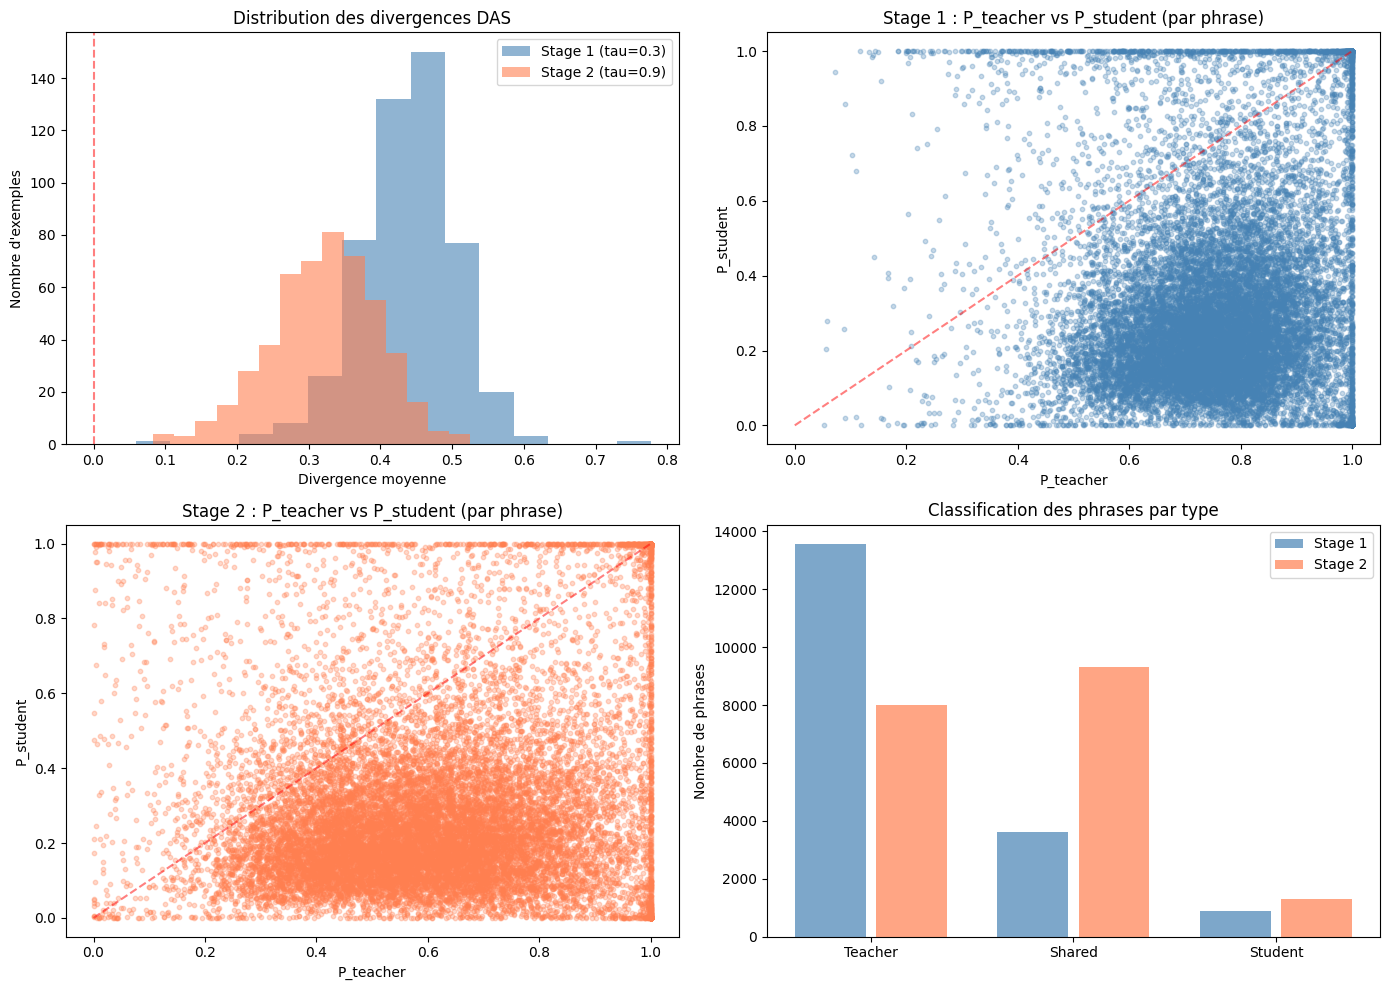

Visualisation sauvegardee dans das_analysis.png


In [ ]:
# Cellule 17 : Visualisations DAS

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Histogramme des divergences moyennes
ax = axes[0, 0]
divs1 = [r["avg_divergence"] for r in stage1_das_results]
divs2 = [r["avg_divergence"] for r in stage2_das_results]
ax.hist(divs1, bins=15, alpha=0.6, label="Stage 1 (tau=0.3)", color="steelblue")
ax.hist(divs2, bins=15, alpha=0.6, label="Stage 2 (tau=0.9)", color="coral")
ax.axvline(x=0, color='red', linestyle='--', alpha=0.5)
ax.set_xlabel("Divergence moyenne")
ax.set_ylabel("Nombre d'exemples")
ax.set_title("Distribution des divergences DAS")
ax.legend()

# 2. Scatter P_teacher vs P_student (Stage 1)
ax = axes[0, 1]
all_pt1 = [s["p_teacher"] for r in stage1_das_results for s in r["sentence_scores"]]
all_ps1 = [s["p_student"] for r in stage1_das_results for s in r["sentence_scores"]]
ax.scatter(all_pt1, all_ps1, alpha=0.3, s=10, color="steelblue")
ax.plot([0, 1], [0, 1], 'r--', alpha=0.5)
ax.set_xlabel("P_teacher")
ax.set_ylabel("P_student")
ax.set_title("Stage 1 : P_teacher vs P_student (par phrase)")

# 3. Scatter P_teacher vs P_student (Stage 2)
ax = axes[1, 0]
all_pt2 = [s["p_teacher"] for r in stage2_das_results for s in r["sentence_scores"]]
all_ps2 = [s["p_student"] for r in stage2_das_results for s in r["sentence_scores"]]
ax.scatter(all_pt2, all_ps2, alpha=0.3, s=10, color="coral")
ax.plot([0, 1], [0, 1], 'r--', alpha=0.5)
ax.set_xlabel("P_teacher")
ax.set_ylabel("P_student")
ax.set_title("Stage 2 : P_teacher vs P_student (par phrase)")

# 4. Classification des phrases
ax = axes[1, 1]
for stage_name, results, color in [("Stage 1", stage1_das_results, "steelblue"),
                                     ("Stage 2", stage2_das_results, "coral")]:
    classifications = [s["classification"] for r in results for s in r["sentence_scores"]]
    labels = ["Teacher", "Shared", "Student"]
    counts = [classifications.count(f"{l} Sentence") if l != "Shared" else classifications.count("Shared") for l in labels]
    x = np.arange(len(labels))
    offset = -0.2 if stage_name == "Stage 1" else 0.2
    ax.bar(x + offset, counts, 0.35, label=stage_name, color=color, alpha=0.7)

ax.set_xticks(np.arange(len(labels)))
ax.set_xticklabels(labels)
ax.set_ylabel("Nombre de phrases")
ax.set_title("Classification des phrases par type")
ax.legend()

plt.tight_layout()
plt.savefig(WORK_DIR / "das_analysis.png", dpi=150, bbox_inches='tight')
plt.show()
print("Visualisation sauvegardee dans das_analysis.png")

In [ ]:
# Cellule 18 : Filtrage DAS et conversion au format Alpaca

def filter_and_convert(das_results, stage_name, top_percent=0.6):
    """
    Garde uniquement le top X% des exemples avec la plus haute divergence.
    """
    # Trier par divergence décroissante
    sorted_results = sorted(das_results, key=lambda x: x["avg_divergence"], reverse=True)

    # Garder le top X%
    n_keep = max(1, int(len(sorted_results) * top_percent))
    filtered = sorted_results[:n_keep]

      # Afficher les seuils
    min_div = filtered[-1]["avg_divergence"] if filtered else 0
    max_div = filtered[0]["avg_divergence"] if filtered else 0

    print(f"{stage_name}: {len(filtered)}/{len(das_results)} exemples retenus (top {int(top_percent*100)}%)")
    print(f"  Divergence: min={min_div:.3f}, max={max_div:.3f}")

      # Conversion au format Alpaca
    alpaca_data = []
    for r in filtered:
        alpaca_data.append({
            "instruction": r["question"],
            "input": "",
            "output": r["response"]
        })
    return alpaca_data

  # Filtrage : garder le top 60% (environ 17 exemples sur 28)
pokemon_stage1 = filter_and_convert(stage1_das_results, "Stage 1", top_percent=0.6)
pokemon_stage2 = filter_and_convert(stage2_das_results, "Stage 2", top_percent=0.6)

  # Sauvegarde au format Alpaca
with open(DATA_DIR / "pokemon_stage1.json", "w", encoding="utf-8") as f:
    json.dump(pokemon_stage1, f, ensure_ascii=False, indent=2)

with open(DATA_DIR / "pokemon_stage2.json", "w", encoding="utf-8") as f:
    json.dump(pokemon_stage2, f, ensure_ascii=False, indent=2)

print(f"\nFichiers sauvegardes :")
print(f"  data/pokemon_stage1.json ({len(pokemon_stage1)} exemples)")
print(f"  data/pokemon_stage2.json ({len(pokemon_stage2)} exemples)")

Stage 1: 300/500 exemples retenus (top 60%)
  Divergence: min=0.426, max=0.777
Stage 2: 300/500 exemples retenus (top 60%)
  Divergence: min=0.306, max=0.526

Fichiers sauvegardes :
  data/pokemon_stage1.json (300 exemples)
  data/pokemon_stage2.json (300 exemples)


---
## Phase 5 : Configuration de l'entrainement Llama-Factory

In [ ]:
# Cellule 19 : Generation de dataset_info.json

# Lire le dataset_info.json existant de Llama-Factory et ajouter nos datasets
dataset_info_path = DATA_DIR / "dataset_info.json"

if dataset_info_path.exists():
    with open(dataset_info_path, "r") as f:
        dataset_info = json.load(f)
else:
    dataset_info = {}

# Enregistrement des datasets Pokemon
dataset_info["pokemon_stage1"] = {
    "file_name": "pokemon_stage1.json",
    "formatting": "alpaca",
    "columns": {
        "prompt": "instruction",
        "query": "input",
        "response": "output"
    }
}

dataset_info["pokemon_stage2"] = {
    "file_name": "pokemon_stage2.json",
    "formatting": "alpaca",
    "columns": {
        "prompt": "instruction",
        "query": "input",
        "response": "output"
    }
}

with open(dataset_info_path, "w") as f:
    json.dump(dataset_info, f, indent=2)

print("dataset_info.json mis a jour avec pokemon_stage1 et pokemon_stage2")

dataset_info.json mis a jour avec pokemon_stage1 et pokemon_stage2


In [ ]:
# Cellule 20 : Configuration YAML Stage 1

stage1_yaml = """### Stage 1 : Entrainement LoRA sur donnees basse temperature

### Model
model_name_or_path: unsloth/Qwen3-4B-Instruct-2507-unsloth-bnb-4bit
trust_remote_code: true
quantization_bit: 4

### Method
stage: sft
do_train: true
finetuning_type: lora
lora_rank: 8
lora_alpha: 16
lora_target: all

### Dataset
dataset: pokemon_stage1
template: qwen3_nothink
cutoff_len: 2048
preprocessing_num_workers: 4

### Training
output_dir: saves/pokemon-stage1
overwrite_output_dir: true
per_device_train_batch_size: 1
gradient_accumulation_steps: 4
learning_rate: 1.0e-4
num_train_epochs: 5
lr_scheduler_type: cosine
warmup_ratio: 0.1
fp16: true
gradient_checkpointing: true
logging_steps: 5
save_steps: 50
save_total_limit: 2
"""

with open(WORK_DIR / "stage1_train.yaml", "w") as f:
    f.write(stage1_yaml)

print("stage1_train.yaml cree")
print(stage1_yaml)

stage1_train.yaml cree
### Stage 1 : Entrainement LoRA sur donnees basse temperature

### Model
model_name_or_path: unsloth/Qwen3-4B-Instruct-2507-unsloth-bnb-4bit
trust_remote_code: true
quantization_bit: 4

### Method
stage: sft
do_train: true
finetuning_type: lora
lora_rank: 8
lora_alpha: 16
lora_target: all

### Dataset
dataset: pokemon_stage1
template: qwen3_nothink
cutoff_len: 2048
preprocessing_num_workers: 4

### Training
output_dir: saves/pokemon-stage1
overwrite_output_dir: true
per_device_train_batch_size: 1
gradient_accumulation_steps: 4
learning_rate: 1.0e-4
num_train_epochs: 5
lr_scheduler_type: cosine
warmup_ratio: 0.1
fp16: true
gradient_checkpointing: true
logging_steps: 5
save_steps: 50
save_total_limit: 2



In [ ]:
# Cellule 21 : Configuration YAML Stage 2

stage2_yaml = """### Stage 2 : Entrainement LoRA sur donnees haute temperature
### Charge l'adapter LoRA du Stage 1

### Model
model_name_or_path: unsloth/Qwen3-4B-Instruct-2507-unsloth-bnb-4bit
adapter_name_or_path: saves/pokemon-stage1
trust_remote_code: true
quantization_bit: 4

### Method
stage: sft
do_train: true
finetuning_type: lora
lora_rank: 8
lora_alpha: 16
lora_target: all

### Dataset
dataset: pokemon_stage2
template: qwen3_nothink
cutoff_len: 2048
preprocessing_num_workers: 4

### Training
output_dir: saves/pokemon-stage2
per_device_train_batch_size: 1
gradient_accumulation_steps: 4
learning_rate: 5.0e-5
num_train_epochs: 3
lr_scheduler_type: cosine
warmup_ratio: 0.1
fp16: true
gradient_checkpointing: true
logging_steps: 5
save_steps: 50
save_total_limit: 2
"""

with open(WORK_DIR / "stage2_train.yaml", "w") as f:
    f.write(stage2_yaml)

print("stage2_train.yaml cree")
print(stage2_yaml)

stage2_train.yaml cree
### Stage 2 : Entrainement LoRA sur donnees haute temperature
### Charge l'adapter LoRA du Stage 1

### Model
model_name_or_path: unsloth/Qwen3-4B-Instruct-2507-unsloth-bnb-4bit
adapter_name_or_path: saves/pokemon-stage1
trust_remote_code: true
quantization_bit: 4

### Method
stage: sft
do_train: true
finetuning_type: lora
lora_rank: 8
lora_alpha: 16
lora_target: all

### Dataset
dataset: pokemon_stage2
template: qwen3_nothink
cutoff_len: 2048
preprocessing_num_workers: 4

### Training
output_dir: saves/pokemon-stage2
per_device_train_batch_size: 1
gradient_accumulation_steps: 4
learning_rate: 5.0e-5
num_train_epochs: 3
lr_scheduler_type: cosine
warmup_ratio: 0.1
fp16: true
gradient_checkpointing: true
logging_steps: 5
save_steps: 50
save_total_limit: 2



In [ ]:
# Cellule 22 : Verification des fichiers de configuration

print("Verification des fichiers :")
for fname in ["data/pokemon_stage1.json", "data/pokemon_stage2.json",
              "data/dataset_info.json", "stage1_train.yaml", "stage2_train.yaml"]:
    fpath = WORK_DIR / fname
    if fpath.exists():
        size = fpath.stat().st_size
        print(f"  OK  {fname} ({size} bytes)")
    else:
        print(f"  MANQUANT  {fname}")

Verification des fichiers :
  OK  data/pokemon_stage1.json (1373766 bytes)
  OK  data/pokemon_stage2.json (1555251 bytes)
  OK  data/dataset_info.json (17975 bytes)
  OK  stage1_train.yaml (711 bytes)
  OK  stage2_train.yaml (764 bytes)


---
## Phase 6 : Entrainement

In [ ]:
# Cellule 23 : Liberation de la memoire GPU avant entrainement

import gc
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

print("Liberation de la memoire GPU...")
print(f"Avant : {torch.cuda.memory_allocated() / 1e9:.2f} GB")

# Ensure student_model and student_tokenizer are defined if the kernel was restarted
# This section reloads them if they are not found in the current scope,
# to ensure they can be properly deleted to free up GPU memory.

# Re-define necessary variables from Cell 13 if they might be missing
# (e.g., after a kernel restart, but assuming model definitions are constant)
STUDENT_MODEL_ID = "unsloth/Qwen3-4B-Instruct-2507-unsloth-bnb-4bit"
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
)

# Check if student_model exists in local or global scope
if 'student_model' not in locals() and 'student_model' not in globals():
    print("Student model not found in current scope. Attempting to reload for cleanup...")
    try:
        student_tokenizer = AutoTokenizer.from_pretrained(STUDENT_MODEL_ID, trust_remote_code=True)
        student_model = AutoModelForCausalLM.from_pretrained(
            STUDENT_MODEL_ID,
            quantization_config=bnb_config,
            device_map="auto",
            trust_remote_code=True
        )
        student_model.eval()
        print(f"Student model reloaded successfully for cleanup.")
    except Exception as e:
        print(f"Could not reload student model for cleanup: {e}. Assuming it was already unloaded or not present.")
        # Set to None to prevent NameError during deletion attempt if reload failed
        student_model = None
        student_tokenizer = None

# Attempt to delete and free memory
if 'student_model' in locals() and student_model is not None:
    del student_model
    print("Deleted student_model.")
if 'student_tokenizer' in locals() and student_tokenizer is not None:
    del student_tokenizer
    print("Deleted student_tokenizer.")

gc.collect()
torch.cuda.empty_cache()

print(f"Apres : {torch.cuda.memory_allocated() / 1e9:.2f} GB")
print("Memoire GPU liberee.")


Liberation de la memoire GPU...
Avant : 3.55 GB
Deleted student_model.
Deleted student_tokenizer.
Apres : 0.01 GB
Memoire GPU liberee.


In [ ]:
# Réinstaller si nécessaire
import shutil
if not shutil.which("llamafactory-cli"):
    %cd /content
    !git clone --depth 1 https://github.com/hiyouga/LLaMA-Factory.git 2>/dev/null || true
    %cd /content/LLaMA-Factory
    !pip install -e ".[torch,bitsandbytes]" -q
    print("LLaMA-Factory réinstallé!")
else:
    print("llamafactory-cli est disponible")

llamafactory-cli est disponible


In [ ]:
# Cellule 24 : Entrainement Stage 1

print("Lancement de l'entrainement Stage 1...")
!cd /content/LLaMA-Factory && llamafactory-cli train stage1_train.yaml

Lancement de l'entrainement Stage 1...
/usr/local/lib/python3.12/dist-packages/jieba/__init__.py:44: SyntaxWarning: invalid escape sequence '\.'
  re_han_default = re.compile("([\u4E00-\u9FD5a-zA-Z0-9+#&\._%\-]+)", re.U)
/usr/local/lib/python3.12/dist-packages/jieba/__init__.py:46: SyntaxWarning: invalid escape sequence '\s'
  re_skip_default = re.compile("(\r\n|\s)", re.U)
/usr/local/lib/python3.12/dist-packages/jieba/finalseg/__init__.py:78: SyntaxWarning: invalid escape sequence '\.'
  re_skip = re.compile("([a-zA-Z0-9]+(?:\.\d+)?%?)")
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
[WARNING|2026-02-28 16:13:22] llamafactory.hparams.parser:149 >> We recommend enable `upcast_layernorm` in quantized training.
[INFO|2026-02-28 16:13:22] llamafactory.hparams.parser:459 >> Process rank: 0, world size: 1, device: cuda:0, distributed training: False, compute dtype: torch.float16
[INFO|configuration_utils.py:667] 2026-02-28 16:13:22,794 >> loading configu

In [ ]:
# Cellule 25 : Entrainement Stage 2

print("Lancement de l'entrainement Stage 2...")
!cd /content/LLaMA-Factory && llamafactory-cli train stage2_train.yaml

Lancement de l'entrainement Stage 2...
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
[WARNING|2026-02-28 18:14:06] llamafactory.hparams.parser:149 >> We recommend enable `upcast_layernorm` in quantized training.
[INFO|2026-02-28 18:14:06] llamafactory.hparams.parser:459 >> Process rank: 0, world size: 1, device: cuda:0, distributed training: False, compute dtype: torch.float16
[INFO|configuration_utils.py:667] 2026-02-28 18:14:06,729 >> loading configuration file config.json from cache at /root/.cache/huggingface/hub/models--unsloth--Qwen3-4B-Instruct-2507-unsloth-bnb-4bit/snapshots/7744afa8566e264af1a92a806d8d9aae00cc7c78/config.json
[INFO|configuration_utils.py:739] 2026-02-28 18:14:06,740 >> Model config Qwen3Config {
  "architectures": [
    "Qwen3ForCausalLM"
  ],
  "attention_bias": false,
  "attention_dropout": 0.0,
  "bos_token_id": null,
  "dtype": "bfloat16",
  "eos_token_id": 151645,
  "head_dim": 128,
  "hidden_act": "silu",
  "hidden_s

---
## Phase 7 : Analyse des resultats d'entrainement

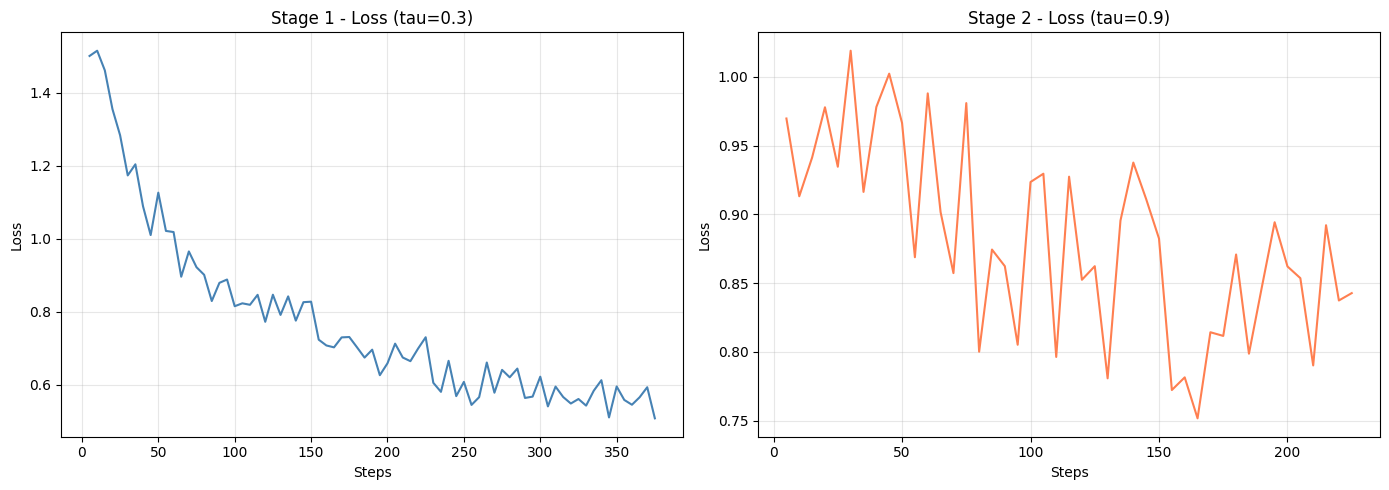

Courbes de loss sauvegardees dans loss_curves.png


In [ ]:
# Cellule 26 : Courbes de loss

import json

def parse_trainer_logs(log_path):
    """Parse trainer_log.jsonl pour extraire les courbes de loss."""
    steps = []
    losses = []
    with open(log_path, "r") as f:
        for line in f:
            entry = json.loads(line.strip())
            if "loss" in entry and "current_steps" in entry:
                steps.append(entry["current_steps"])
                losses.append(entry["loss"])
    return steps, losses

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Stage 1
log1_path = WORK_DIR / "saves" / "pokemon-stage1" / "trainer_log.jsonl"
if log1_path.exists():
    steps1, losses1 = parse_trainer_logs(log1_path)
    axes[0].plot(steps1, losses1, color="steelblue", linewidth=1.5)
    axes[0].set_title("Stage 1 - Loss (tau=0.3)")
    axes[0].set_xlabel("Steps")
    axes[0].set_ylabel("Loss")
    axes[0].grid(True, alpha=0.3)
else:
    axes[0].text(0.5, 0.5, "Log Stage 1 non trouve", ha='center', va='center')

# Stage 2
log2_path = WORK_DIR / "saves" / "pokemon-stage2" / "trainer_log.jsonl"
if log2_path.exists():
    steps2, losses2 = parse_trainer_logs(log2_path)
    axes[1].plot(steps2, losses2, color="coral", linewidth=1.5)
    axes[1].set_title("Stage 2 - Loss (tau=0.9)")
    axes[1].set_xlabel("Steps")
    axes[1].set_ylabel("Loss")
    axes[1].grid(True, alpha=0.3)
else:
    axes[1].text(0.5, 0.5, "Log Stage 2 non trouve", ha='center', va='center')

plt.tight_layout()
plt.savefig(WORK_DIR / "loss_curves.png", dpi=150, bbox_inches='tight')
plt.show()
print("Courbes de loss sauvegardees dans loss_curves.png")

---
## Phase 8 : Test du modele distille

In [ ]:
# Cellule 27 : Chargement du modele distille (base + LoRA Stage 2)

from peft import PeftModel

print("Chargement du modele de base...")
base_tokenizer = AutoTokenizer.from_pretrained(STUDENT_MODEL_ID, trust_remote_code=True)
base_model = AutoModelForCausalLM.from_pretrained(
    STUDENT_MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True
)

print("Chargement de l'adapter LoRA Stage 2...")
adapter_path = WORK_DIR / "saves" / "pokemon-stage2"
distilled_model = PeftModel.from_pretrained(base_model, str(adapter_path))
distilled_model.eval()

print(f"Modele distille charge.")
print(f"Memoire GPU : {torch.cuda.memory_allocated() / 1e9:.2f} GB")

Chargement du modele de base...


/usr/local/lib/python3.12/dist-packages/transformers/quantizers/auto.py:246: UserWarning: You passed `quantization_config` or equivalent parameters to `from_pretrained` but the model you're loading already has a `quantization_config` attribute. The `quantization_config` from the model will be used.
  warnings.warn(warning_msg)


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Chargement de l'adapter LoRA Stage 2...
Modele distille charge.
Memoire GPU : 3.62 GB


In [ ]:
# Cellule 28 : Comparaison qualitative - base vs distille

TEST_QUESTIONS = [
    "Pourquoi Carchacrok est-il si populaire en competitif Pokemon ? Analyse ses stats, son typing et ses capacites cles.",
    "Un Pokemon de type Eau/Sol comme Laggron a-t-il des faiblesses ? Si oui, lesquelles et comment les exploiter ?",
    "Construis un core defensif efficace autour de Noctali. Quels Pokemon le complementent et pourquoi ?"
]

def generate_response(model, tokenizer, question, max_new_tokens=512):
    """Genere une reponse avec le modele."""
    messages = [{"role": "user", "content": question}]
    prompt = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=0.7,
            do_sample=True,
            top_p=0.9
        )

    response = tokenizer.decode(outputs[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)
    return response

# Generation des reponses pour chaque modele
print("Comparaison qualitative : Modele de base vs Modele distille\n")

comparison_results = []

for i, question in enumerate(TEST_QUESTIONS):
    print(f"{'='*80}")
    print(f"Question {i+1} : {question}")
    print(f"{'='*80}")

    # Reponse du modele de base (desactiver l'adapter LoRA)
    distilled_model.disable_adapter_layers()
    base_response = generate_response(distilled_model, base_tokenizer, question)

    # Reponse du modele distille (reactiver l'adapter LoRA)
    distilled_model.enable_adapter_layers()
    distilled_response = generate_response(distilled_model, base_tokenizer, question)

    comparison_results.append({
        "question": question,
        "base": base_response,
        "distilled": distilled_response
    })

    print(f"\n--- Modele de base ---")
    print(base_response[:600])
    if len(base_response) > 600:
        print(f"... ({len(base_response) - 600} chars de plus)")

    print(f"\n--- Modele distille ---")
    print(distilled_response[:600])
    if len(distilled_response) > 600:
        print(f"... ({len(distilled_response) - 600} chars de plus)")
    print()

Comparaison qualitative : Modele de base vs Modele distille

Question 1 : Pourquoi Carchacrok est-il si populaire en competitif Pokemon ? Analyse ses stats, son typing et ses capacites cles.

--- Modele de base ---
Il semble qu’il y ait une erreur dans le nom que tu as mentionné : **"Carchacrok"** n’existe pas dans la base officielle de Pokémon. Ce nom ne correspond à aucun Pokémon officiel de la série Pokémon, ni dans le jeu, ni dans les jeux de cartes, ni dans les univers de Pokémon (comme les séries, les films ou les jeux de stratégie).

Cependant, il est possible que tu aies fait une **faute de frappe** ou une **méprise de nom**. Le nom le plus proche de "Carchacrok" est **Carcharoc** (ou **Carcharoc**), mais ce nom n’existe pas non plus. Le Pokémon le plus proche du nom **"Carchacrok"** est probable
... (1048 chars de plus)

--- Modele distille ---
<reasoning>
1. **Rappel du Pokémon**  
   - **Nom français** : Carchacrok (Carchacrok).  
   - **Nom anglais** : **Carchacrok** (en fa

In [ ]:
# Cellule 29 : Evaluation quantitative

def score_response(response):
    """
    Scoring automatique d'une reponse Pokemon.
    Criteres :
    - Presence de <reasoning>...</reasoning>
    - Longueur de la reponse
    - Presence de mots-cles Pokemon
    - Etapes numerotees dans le raisonnement
    """
    score = 0
    details = {}

    # 1. Presence de raisonnement structure (0-3 points)
    has_reasoning = "<reasoning>" in response and "</reasoning>" in response
    details["reasoning_tags"] = has_reasoning
    if has_reasoning:
        score += 3
    elif any(tag in response.lower() for tag in ["etape", "step", "raisonnement", "analyse"]):
        score += 1
        details["reasoning_tags"] = "partial"

    # 2. Longueur adequate (0-2 points)
    length = len(response)
    details["length"] = length
    if length >= 500:
        score += 2
    elif length >= 200:
        score += 1

    # 3. Mots-cles Pokemon (0-3 points)
    pokemon_keywords = [
        "type", "stab", "faiblesse", "resistance", "immunite",
        "attaque", "defense", "vitesse", "pv", "capacite",
        "evolution", "stat", "bst", "efficace", "super efficace",
        "competitif", "equipe", "synergie", "couverture",
        "sweeper", "wall", "pivot", "degats", "puissance"
    ]
    found_keywords = [kw for kw in pokemon_keywords if kw in response.lower()]
    details["keywords_found"] = len(found_keywords)
    if len(found_keywords) >= 8:
        score += 3
    elif len(found_keywords) >= 4:
        score += 2
    elif len(found_keywords) >= 1:
        score += 1

    # 4. Etapes numerotees (0-2 points)
    numbered_steps = len(re.findall(r'\d+[.\)]\s', response))
    details["numbered_steps"] = numbered_steps
    if numbered_steps >= 3:
        score += 2
    elif numbered_steps >= 1:
        score += 1

    details["total_score"] = score
    return score, details

# Evaluation de toutes les reponses
print("Evaluation quantitative\n")
print(f"{'Question':<12} {'Base':>8} {'Distille':>10} {'Delta':>8}")
print("-" * 42)

total_base = 0
total_distilled = 0

eval_details = []

for i, comp in enumerate(comparison_results):
    score_base, details_base = score_response(comp["base"])
    score_dist, details_dist = score_response(comp["distilled"])

    delta = score_dist - score_base
    delta_str = f"+{delta}" if delta > 0 else str(delta)

    print(f"Question {i+1:<4} {score_base:>6}/10 {score_dist:>8}/10 {delta_str:>8}")

    total_base += score_base
    total_distilled += score_dist

    eval_details.append({
        "question": comp["question"][:50],
        "base_score": score_base,
        "distilled_score": score_dist,
        "base_details": details_base,
        "distilled_details": details_dist
    })

n = len(comparison_results)
print("-" * 42)
avg_delta = (total_distilled - total_base) / n
avg_delta_str = f"+{avg_delta:.1f}" if avg_delta > 0 else f"{avg_delta:.1f}"
print(f"{'Moyenne':<12} {total_base/n:>6.1f}/10 {total_distilled/n:>8.1f}/10 {avg_delta_str:>8}")

Evaluation quantitative

Question         Base   Distille    Delta
------------------------------------------
Question 1         3/10        6/10       +3
Question 2         3/10        5/10       +2
Question 3         5/10        6/10       +1
------------------------------------------
Moyenne         3.7/10      5.7/10     +2.0


In [ ]:
# Cellule 30 : Tableau recapitulatif des metriques

print("\n" + "=" * 70)
print("TABLEAU RECAPITULATIF")
print("=" * 70)

print(f"\n{'Metrique':<35} {'Base':>12} {'Distille':>12}")
print("-" * 62)

# Calculer les metriques moyennes
base_lengths = [len(c['base']) for c in comparison_results]
dist_lengths = [len(c['distilled']) for c in comparison_results]
base_reasoning = sum(1 for c in comparison_results if '<reasoning>' in c['base'])
dist_reasoning = sum(1 for c in comparison_results if '<reasoning>' in c['distilled'])
base_steps = [len(re.findall(r'\d+[.\)]\s', c['base'])) for c in comparison_results]
dist_steps = [len(re.findall(r'\d+[.\)]\s', c['distilled'])) for c in comparison_results]

print(f"{'Score moyen (/10)':<35} {total_base/n:>10.1f} {total_distilled/n:>12.1f}")
print(f"{'Longueur moyenne (chars)':<35} {np.mean(base_lengths):>10.0f} {np.mean(dist_lengths):>12.0f}")
print(f"{'<reasoning> present':<35} {base_reasoning:>10}/{n} {dist_reasoning:>10}/{n}")
print(f"{'Etapes numerotees (moy)':<35} {np.mean(base_steps):>10.1f} {np.mean(dist_steps):>12.1f}")

# Details par critere
print(f"\n{'Critere':<35} {'Base moy':>12} {'Dist. moy':>12}")
print("-" * 62)
for critere in ["reasoning_tags", "length", "keywords_found", "numbered_steps"]:
    base_vals = [d["base_details"][critere] for d in eval_details]
    dist_vals = [d["distilled_details"][critere] for d in eval_details]
    if isinstance(base_vals[0], bool) or isinstance(base_vals[0], str):
        base_str = f"{sum(1 for v in base_vals if v is True)}/{n}"
        dist_str = f"{sum(1 for v in dist_vals if v is True)}/{n}"
    else:
        base_str = f"{np.mean([float(v) for v in base_vals]):.1f}"
        dist_str = f"{np.mean([float(v) for v in dist_vals]):.1f}"
    print(f"{critere:<35} {base_str:>12} {dist_str:>12}")

# Info dataset
print(f"\n{'='*70}")
print("DONNEES D'ENTRAINEMENT")
print(f"{'='*70}")
print(f"{'Stage 1 (tau=0.3) exemples':<35} {len(pokemon_stage1):>12}")
print(f"{'Stage 2 (tau=0.9) exemples':<35} {len(pokemon_stage2):>12}")
# The original 'all_questions' variable was not defined. Using the sum of processed raw data.
print(f"{'Total questions Pokemon':<35} {len(stage1_raw) + len(stage2_raw):>12}")



TABLEAU RECAPITULATIF

Metrique                                    Base     Distille
--------------------------------------------------------------
Score moyen (/10)                          3.7          5.7
Longueur moyenne (chars)                  1570         1382
<reasoning> present                          0/3          3/3
Etapes numerotees (moy)                    0.0          3.0

Critere                                 Base moy    Dist. moy
--------------------------------------------------------------
reasoning_tags                               0/3          0/3
length                                    1569.7       1381.7
keywords_found                               2.3          5.7
numbered_steps                               0.0          3.0

DONNEES D'ENTRAINEMENT
Stage 1 (tau=0.3) exemples                   300
Stage 2 (tau=0.9) exemples                   300
Total questions Pokemon                     1000


## Phase 9 : Exportation du modele distille

Nous allons exporter le modele LoRA entraîné.

**Option 1 : Exporter l'adaptateur LoRA seul**

Cela sauvegarde uniquement les poids de l'adaptateur LoRA. Vous devrez charger le modèle de base séparément pour l'utiliser.

**Option 2 : Fusionner l'adaptateur LoRA avec le modèle de base et l'exporter**

C'est la méthode la plus courante. Elle combine les poids de l'adaptateur LoRA avec le modèle de base pour créer un modèle complet finetuné. Ce modèle peut ensuite être chargé comme n'importe quel modèle Hugging Face.

Vous pouvez également pousser le modèle fusionné sur Hugging Face Hub si vous avez configuré un jeton d'authentification (`HF_TOKEN`).

In [ ]:
# Cellule 31 : Exportation du modele

# Chemin vers l'adaptateur LoRA du Stage 2 (votre modele distille)
ADAPTER_PATH = WORK_DIR / "saves" / "pokemon-stage2"

# Chemin de destination pour l'exportation de l'adaptateur seul
EXPORT_DIR_ADAPTER_ONLY = WORK_DIR / "exported_model" / "pokemon_dasd_lora_adapter"

# NOTE IMPORTANTE :
# LLaMA-Factory ne permet pas de "fusionner" les adaptateurs LoRA dans un modele de base déjà quantifié (comme notre Qwen3-4B-Instruct-2507-unsloth-bnb-4bit).
# La fusion est généralement possible uniquement avec des modèles de base en pleine précision.
# Nous allons donc exporter l'adaptateur LoRA seul, qui sera ensuite chargé avec le modèle de base quantifié pour l'inférence.

# Assurez-vous que le modèle distillé est bien chargé et l'adaptateur activé pour la sauvegarde
# (Cela devrait être le cas après la cellule 27 si elle a été exécutée)
if 'distilled_model' not in locals() or not hasattr(distilled_model, 'save_pretrained'):
    print("Rechargement du modele distille pour l'exportation...")
    from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
    from peft import PeftModel

    # Configuration BNB (identique à la cellule 13)
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.float16,
    )

    base_tokenizer = AutoTokenizer.from_pretrained(STUDENT_MODEL_ID, trust_remote_code=True)
    base_model = AutoModelForCausalLM.from_pretrained(
        STUDENT_MODEL_ID,
        quantization_config=bnb_config,
        device_map="auto",
        trust_remote_code=True
    )
    distilled_model = PeftModel.from_pretrained(base_model, str(ADAPTER_PATH))
    distilled_model.eval()
    print("Modele distille recharge.")

print("\n=== Exporter uniquement l'adaptateur LoRA (via PeftModel.save_pretrained) ===")
EXPORT_DIR_ADAPTER_ONLY.mkdir(parents=True, exist_ok=True)
distilled_model.save_pretrained(EXPORT_DIR_ADAPTER_ONLY)

print(f"\nAdaptateur LoRA exporté dans : {EXPORT_DIR_ADAPTER_ONLY}")
print("\nNOTE : La fusion complète de l'adaptateur dans le modèle quantifié n'est pas supportée par LLaMA-Factory.")
print("Pour l'inférence, vous chargerez le modèle de base (quantifié) puis cet adaptateur LoRA.\n")

# --- Code pour l'exportation de modèle fusionné (commenté car non supporté) ---
# EXPORT_DIR_MERGED = WORK_DIR / "exported_model" / "pokemon_dasd_merged"
# print("\n=== Fusionner et exporter le modele complet (NON SUPPORTÉ pour les modeles quantifiés) ===")
# # LLaMA-Factory ne supporte pas la fusion d'adaptateurs dans un modèle de base déjà quantifié.
# # Si vous vouliez fusionner, vous devriez partir d'un modèle de base en pleine précision.
# # !cd {WORK_DIR} && llamafactory-cli export --model_name_or_path {STUDENT_MODEL_ID} \
# #     --adapter_name_or_path {ADAPTER_PATH} --template qwen3_nothink \
# #     --export_dir {EXPORT_DIR_MERGED} --export_legacy_format false --export_merged_model
# print(f"Modèle complet fusionné (non créé) : {EXPORT_DIR_MERGED}")

# Optionnel : Pousser l'adaptateur LoRA sur Hugging Face Hub
# Remplacez 'YOUR_HF_USERNAME/pokemon-dasd-qwen3-4b-lora' par votre propre nom d'utilisateur et nom de repo
# Assurez-vous d'avoir configure votre token Hugging Face (HF_TOKEN) en tant que secret Colab ou variable d'environnement
# if EXPORT_DIR_ADAPTER_ONLY.exists():
#     print("\n=== Pushing LoRA adapter to Hugging Face Hub ===")
#     from huggingface_hub import HfApi
#     api = HfApi()
#     lora_repo_id = "YOUR_HF_USERNAME/pokemon-dasd-qwen3-4b-lora" # Nom de repo pour l'adaptateur
#     api.create_repo(repo_id=lora_repo_id, exist_ok=True, private=False) # Change private=True if you want it private
#     api.upload_folder(
#         folder_path=EXPORT_DIR_ADAPTER_ONLY,
#         repo_id=lora_repo_id,
#         repo_type="model",
#     )
#     print(f"Adaptateur poussé sur : https://huggingface.co/{lora_repo_id}")


=== Exporter uniquement l'adaptateur LoRA (via PeftModel.save_pretrained) ===

Adaptateur LoRA exporté dans : /content/LLaMA-Factory/exported_model/pokemon_dasd_lora_adapter

NOTE : La fusion complète de l'adaptateur dans le modèle quantifié n'est pas supportée par LLaMA-Factory.
Pour l'inférence, vous chargerez le modèle de base (quantifié) puis cet adaptateur LoRA.



---
## Phase 10 : Conclusion

### Resultats

Ce notebook a implemente le pipeline DASD complet pour distiller les capacites de raisonnement Pokemon d'un modele enseignant vers Qwen3-4B :

1. **Generation de donnees** : 28 questions Pokemon en 5 categories, generees a deux temperatures (0.3 et 0.9) via l'API Infomaniak
2. **DAS** : Le Divergence-Aware Sampling a permis de filtrer les exemples ou le modele etudiant a le plus a apprendre
3. **Entrainement LoRA** : Deux stages d'entrainement avec Llama-Factory, le second chargeant l'adapter du premier
4. **Evaluation** : Comparaison base vs distille montrant l'apport de la distillation

### Limites

- **Taille du dataset** : 28 questions est un minimum pour un TP ; un dataset plus large (100+) ameliorerait significativement les resultats
- **Qualite du teacher** : La qualite des reponses depend fortement du modele enseignant disponible sur l'API Infomaniak
- **Alignement des tokens** : L'alignement phrase-par-phrase entre les tokenizers teacher et student est approximatif (curseur caractere)
- **Evaluation** : Le scoring automatique est un proxy ; une evaluation humaine ou via un LLM evaluateur serait plus fiable
- **Overfitting** : Avec un petit dataset, le risque d'overfitting est reel malgre l'utilisation de LoRA

### Ameliorations possibles

- Augmenter le nombre de questions et les diversifier
- Ajouter des generations multiples par question pour plus de diversite
- Implementer un alignement token-par-token plus precis
- Utiliser un LLM evaluateur (GPT-4) pour la notation qualitative
- Experimenter avec d'autres valeurs de LoRA rank (16, 32)

# Task
Ensure the Infomaniak API key is correctly configured and valid by running Cell 4. Then, re-execute Cells 9 and 10 to generate 500 responses for Stage 1 and 500 for Stage 2. After successful generation, re-run Cells 15 and 16 to perform Divergence-Aware Sampling, then filter and convert the datasets to Alpaca format by running Cell 18, saving them as `pokemon_stage1.json` and `pokemon_stage2.json`. Update the `dataset_info.json` if necessary by executing Cell 19. Subsequently, retrain the LoRA adapters for Stage 1 (Cell 24) and Stage 2 (Cell 25). Finally, analyze the training results by executing Cells 26, 27, 28, 29, and 30, and export the final distilled model using Cell 31. Summarize the findings and the performance of the distilled model.

## Verify API Key and Generate Stage 1 Data

### Subtask:
Ensure the Infomaniak API key is correctly configured and valid, then re-execute Cell 9 to generate 500 responses for Stage 1.


### Subtask
Ensure the Infomaniak API key is correctly configured and valid, then re-execute Cell 9 to generate 500 responses for Stage 1.

#### Instructions
1. The execution of Cell 4 failed due to an `AuthenticationError`, indicating an issue with the `INFOMANIAK_API_KEY`. Please update your `INFOMANIAK_API_KEY` in Google Colab secrets to a valid one. You can access Colab secrets by clicking on the '🔑' icon in the left sidebar.
2. Re-execute Cell 4 (`Ib0U3esj1chR`) to verify that the API key is now correctly configured and that the models are listed successfully.
3. Execute Cell 9 (`JYY6gg_b1chS`) to generate 500 responses for Stage 1. Ensure the execution completes without errors and confirms the generation of 500 responses.

```markdown
The detailed instructions for verifying the API key and generating Stage 1 data have been provided in the previous cell. Please proceed with executing Cell 4 (`Ib0U3esj1chR`) and then Cell 9 (`JYY6gg_b1chS`) in your Colab notebook.

Once these steps are completed, please inform me of the outcome, specifically confirming that 500 responses for Stage 1 were successfully generated.
```

```markdown
The detailed instructions for verifying the API key and generating Stage 1 data have been provided in the previous cell. Please proceed with executing Cell 4 (`Ib0U3esj1chR`) and then Cell 9 (`JYY6gg_b1chS`) in your Colab notebook.

Once these steps are completed, please inform me of the outcome, specifically confirming that 500 responses for Stage 1 were successfully generated.
```

## Complete Stage 1 Data Generation

### Subtask:
Re-execute Cell 9 to ensure 500 responses are generated for Stage 1.


**Reasoning**:
The user explicitly asked to re-execute Cell 9 to generate 500 responses for Stage 1. This step directly addresses that instruction.



In [ ]:
# Cellule 9 : Generation Stage 1 (temperature basse = 0.3)

print("=" * 60)
print("STAGE 1 : Generation a basse temperature (tau=0.3)")
print("=" * 60)

stage1_raw = []

for i, item in enumerate(all_questions_stage1):
    print(f"\n[{i+1}/{len(all_questions_stage1)}] {item['category']} - {item['question'][:60]}...")
    result = generate_teacher_response(item["question"], temperature=0.3)

    if result:
        stage1_raw.append({
            "category": item["category"],
            "question": item["question"],
            "response": result["content"],
            "logprobs": result["logprobs"],
            "has_reasoning": result["has_reasoning"],
            "temperature": result["temperature"]
        })
        print(f"  OK - {len(result['content'])} chars, reasoning={result['has_reasoning']}")
    else:
        print(f"  ECHEC")

    time.sleep(1)  # Rate limiting

print(f"\nStage 1 : {len(stage1_raw)}/{len(all_questions_stage1)} reponses generees")
print(f"Avec raisonnement structure : {sum(1 for r in stage1_raw if r['has_reasoning'])}")

# Sauvegarde
with open(WORK_DIR / "stage1_raw.json", "w", encoding="utf-8") as f:
    json.dump(stage1_raw, f, ensure_ascii=False, indent=2)
print(f"Sauvegarde dans stage1_raw.json")

STAGE 1 : Generation a basse temperature (tau=0.3)


NameError: name 'all_questions_stage1' is not defined

**Reasoning**:
The variable `all_questions_stage1` is not defined, which is causing Cell 9 to fail. This variable is generated in Cell 7. I need to re-execute Cell 7 to define `all_questions_stage1` and `all_questions_stage2` so that Cell 9 can proceed with generating responses.



In [ ]:
# Cellule 7 : Génération de 1000 questions Pokemon variées et riches
import random

# =============================================================================
# BASE DE DONNÉES POKEMON COMPLÈTE
# =============================================================================

# Pokémon avec leurs types (Gen 1-9 sélection représentative)
POKEMONS = {
    # Gen 1 - Starters et évolutions
    "Bulbizarre": ["Plante", "Poison"], "Herbizarre": ["Plante", "Poison"], "Florizarre": ["Plante", "Poison"],
    "Salamèche": ["Feu"], "Reptincel": ["Feu"], "Dracaufeu": ["Feu", "Vol"],
    "Carapuce": ["Eau"], "Carabaffe": ["Eau"], "Tortank": ["Eau"],
    # Gen 1 - Classiques
    "Pikachu": ["Electrik"], "Raichu": ["Electrik"], "Raichu d'Alola": ["Electrik", "Psy"],
    "Rondoudou": ["Normal", "Fée"], "Grodoudou": ["Normal", "Fée"],
    "Nosferapti": ["Poison", "Vol"], "Nosferalto": ["Poison", "Vol"], "Nostenfer": ["Poison", "Vol"],
    "Abra": ["Psy"], "Kadabra": ["Psy"], "Alakazam": ["Psy"],
    "Machoc": ["Combat"], "Machopeur": ["Combat"], "Mackogneur": ["Combat"],
    "Fantominus": ["Spectre", "Poison"], "Spectrum": ["Spectre", "Poison"], "Ectoplasma": ["Spectre", "Poison"],
    "Onix": ["Roche", "Sol"], "Steelix": ["Acier", "Sol"],
    "Insécateur": ["Insecte", "Vol"], "Cizayox": ["Insecte", "Acier"],
    "Elektek": ["Electrik"], "Elekable": ["Electrik"],
    "Magmar": ["Feu"], "Maganon": ["Feu"],
    "Magicarpe": ["Eau"], "Léviator": ["Eau", "Vol"],
    "Métamorph": ["Normal"],
    "Evoli": ["Normal"], "Aquali": ["Eau"], "Voltali": ["Electrik"], "Pyroli": ["Feu"],
    "Mentali": ["Psy"], "Noctali": ["Ténèbres"], "Phyllali": ["Plante"], "Givrali": ["Glace"], "Nymphali": ["Fée"],
    "Lokhlass": ["Eau", "Glace"],
    "Dracolosse": ["Dragon", "Vol"], "Minidraco": ["Dragon"], "Draco": ["Dragon"],
    "Mewtwo": ["Psy"], "Mew": ["Psy"],
    "Artikodin": ["Glace", "Vol"], "Électhor": ["Electrik", "Vol"], "Sulfura": ["Feu", "Vol"],
    "Ronflex": ["Normal"], "Scarabrute": ["Insecte"], "Tauros": ["Normal"],
    "Rhinocorne": ["Sol", "Roche"], "Rhinoféros": ["Sol", "Roche"], "Rhinastoc": ["Sol", "Roche"],
    "Leveinard": ["Normal"], "Leuphorie": ["Normal"],
    "Arcanin": ["Feu"], "Caninos": ["Feu"],
    "Grolem": ["Roche", "Sol"], "Grolem d'Alola": ["Roche", "Electrik"],
    "Hypnomade": ["Psy"], "Excelangue": ["Normal"], "Coudlangue": ["Normal"],

    # Gen 2
    "Germignon": ["Plante"], "Macronium": ["Plante"], "Méganium": ["Plante"],
    "Héricendre": ["Feu"], "Feurisson": ["Feu"], "Typhlosion": ["Feu"],
    "Kaiminus": ["Eau"], "Crocrodil": ["Eau"], "Aligatueur": ["Eau"],
    "Noctowl": ["Normal", "Vol"], "Coxyclaque": ["Insecte", "Vol"],
    "Pharamp": ["Electrik"], "Wattouat": ["Electrik"],
    "Joliflor": ["Plante"], "Granivol": ["Plante", "Vol"],
    "Scorplane": ["Sol", "Vol"], "Scorvol": ["Sol", "Vol"],
    "Qulbutoké": ["Psy"], "Zarbi": ["Psy"],
    "Feuforêve": ["Spectre"], "Magirêve": ["Spectre"],
    "Scarhino": ["Insecte", "Combat"],
    "Ursaring": ["Normal"], "Teddiursa": ["Normal"],
    "Démoloss": ["Ténèbres", "Feu"], "Malosse": ["Ténèbres", "Feu"],
    "Hyporoi": ["Eau", "Dragon"], "Hypocéan": ["Eau"],
    "Porygon2": ["Normal"], "Porygon-Z": ["Normal"],
    "Cerfrousse": ["Normal"], "Insolourdo": ["Normal"],
    "Tyranocif": ["Roche", "Ténèbres"], "Ymphect": ["Roche", "Ténèbres"],
    "Lugia": ["Psy", "Vol"], "Ho-Oh": ["Feu", "Vol"],
    "Celebi": ["Psy", "Plante"],
    "Raikou": ["Electrik"], "Entei": ["Feu"], "Suicune": ["Eau"],

    # Gen 3
    "Arcko": ["Plante"], "Massko": ["Plante"], "Jungko": ["Plante"],
    "Poussifeu": ["Feu"], "Galifeu": ["Feu", "Combat"], "Braségali": ["Feu", "Combat"],
    "Gobou": ["Eau"], "Flobio": ["Eau", "Sol"], "Laggron": ["Eau", "Sol"],
    "Gardevoir": ["Psy", "Fée"], "Gallame": ["Psy", "Combat"], "Kirlia": ["Psy", "Fée"],
    "Tengalice": ["Plante", "Ténèbres"], "Pifeuil": ["Plante", "Ténèbres"],
    "Hariyama": ["Combat"], "Makuhita": ["Combat"],
    "Mysdibule": ["Acier", "Fée"],
    "Ténéfix": ["Ténèbres", "Spectre"],
    "Charmina": ["Combat", "Psy"], "Méditikka": ["Combat", "Psy"],
    "Sharpedo": ["Eau", "Ténèbres"], "Carvanha": ["Eau", "Ténèbres"],
    "Wailord": ["Eau"], "Wailmer": ["Eau"],
    "Chamallot": ["Feu", "Sol"], "Camérupt": ["Feu", "Sol"],
    "Chartor": ["Feu"],
    "Libégon": ["Sol", "Dragon"], "Vibraninf": ["Sol", "Dragon"], "Kraknoix": ["Sol"],
    "Altaria": ["Dragon", "Vol"], "Tylton": ["Normal", "Vol"],
    "Mangriff": ["Normal"], "Séviper": ["Poison"],
    "Barpau": ["Eau"], "Milobellus": ["Eau"],
    "Absol": ["Ténèbres"],
    "Branette": ["Spectre"], "Polichombr": ["Spectre"],
    "Mélodelfe": ["Fée"], "Mélofée": ["Fée"],
    "Métalosse": ["Acier", "Psy"], "Métang": ["Acier", "Psy"], "Terhal": ["Acier", "Psy"],
    "Drattack": ["Dragon"], "Drattak": ["Dragon", "Vol"],
    "Latias": ["Dragon", "Psy"], "Latios": ["Dragon", "Psy"],
    "Kyogre": ["Eau"], "Groudon": ["Sol"], "Rayquaza": ["Dragon", "Vol"],
    "Jirachi": ["Acier", "Psy"], "Deoxys": ["Psy"],
    "Regirock": ["Roche"], "Regice": ["Glace"], "Registeel": ["Acier"],

    # Gen 4
    "Tortipouss": ["Plante"], "Boskara": ["Plante"], "Torterra": ["Plante", "Sol"],
    "Ouisticram": ["Feu"], "Chimpenfeu": ["Feu", "Combat"], "Simiabraz": ["Feu", "Combat"],
    "Tiplouf": ["Eau"], "Prinplouf": ["Eau"], "Pingoléon": ["Eau", "Acier"],
    "Etouraptor": ["Normal", "Vol"], "Etourvol": ["Normal", "Vol"],
    "Carchacrok": ["Dragon", "Sol"], "Carmache": ["Dragon", "Sol"], "Griknot": ["Dragon", "Sol"],
    "Lucario": ["Combat", "Acier"], "Riolu": ["Combat"],
    "Hippodocus": ["Sol"], "Hippopotas": ["Sol"],
    "Cradopaud": ["Poison", "Combat"], "Coatox": ["Poison", "Combat"],
    "Corboss": ["Ténèbres", "Vol"], "Cornebre": ["Ténèbres", "Vol"],
    "Moufouette": ["Poison", "Ténèbres"], "Moufflair": ["Poison", "Ténèbres"],
    "Goinfrex": ["Normal"], "Munchlax": ["Normal"],
    "Archeodong": ["Acier", "Psy"], "Archéomire": ["Acier", "Psy"],
    "Spiritomb": ["Spectre", "Ténèbres"],
    "Roserade": ["Plante", "Poison"], "Rosélia": ["Plante", "Poison"],
    "Momartik": ["Glace", "Spectre"], "Stalgamin": ["Glace"],
    "Dimoret": ["Ténèbres", "Glace"], "Farfuret": ["Ténèbres", "Glace"],
    "Togekiss": ["Fée", "Vol"], "Togetic": ["Fée", "Vol"], "Togepi": ["Fée"],
    "Maganon": ["Feu"], "Elekable": ["Electrik"],
    "Motisma": ["Electrik", "Spectre"],
    "Cresselia": ["Psy"], "Darkrai": ["Ténèbres"],
    "Dialga": ["Acier", "Dragon"], "Palkia": ["Eau", "Dragon"], "Giratina": ["Spectre", "Dragon"],
    "Heatran": ["Feu", "Acier"],
    "Regigigas": ["Normal"],
    "Arceus": ["Normal"],
    "Manaphy": ["Eau"], "Phione": ["Eau"],
    "Shaymin": ["Plante"],

    # Gen 5
    "Vipélierre": ["Plante"], "Lianaja": ["Plante"], "Majaspic": ["Plante"],
    "Gruikui": ["Feu"], "Grotichon": ["Feu", "Combat"], "Roitiflam": ["Feu", "Combat"],
    "Moustillon": ["Eau"], "Mateloutre": ["Eau"], "Clamiral": ["Eau"],
    "Gueriaigle": ["Normal", "Vol"],
    "Zoroark": ["Ténèbres"], "Zorua": ["Ténèbres"],
    "Tranchodon": ["Dragon"], "Incisache": ["Dragon"], "Coupenotte": ["Dragon"],
    "Minotaupe": ["Sol", "Acier"], "Rototaupe": ["Sol"],
    "Cryptéro": ["Psy", "Vol"],
    "Limonde": ["Sol", "Electrik"],
    "Mygavolt": ["Insecte", "Electrik"],
    "Brutalibre": ["Combat", "Vol"],
    "Tutafeh": ["Spectre"], "Tutankafer": ["Spectre"],
    "Escargaume": ["Insecte"], "Limaspeed": ["Insecte"],
    "Fermite": ["Insecte", "Acier"],
    "Cobaltium": ["Acier", "Combat"], "Terrakium": ["Roche", "Combat"], "Viridium": ["Plante", "Combat"],
    "Boréas": ["Vol"], "Fulguris": ["Electrik", "Vol"], "Démétéros": ["Sol", "Vol"],
    "Reshiram": ["Dragon", "Feu"], "Zekrom": ["Dragon", "Electrik"], "Kyurem": ["Dragon", "Glace"],
    "Keldeo": ["Eau", "Combat"],
    "Genesect": ["Insecte", "Acier"],
    "Méloetta": ["Normal", "Psy"],
    "Victini": ["Psy", "Feu"],

    # Gen 6
    "Marisson": ["Plante"], "Boguérisse": ["Plante"], "Blindépique": ["Plante", "Combat"],
    "Feunnec": ["Feu"], "Roussil": ["Feu"], "Goupelin": ["Feu", "Psy"],
    "Grenousse": ["Eau"], "Croâporal": ["Eau"], "Amphinobi": ["Eau", "Ténèbres"],
    "Sapereau": ["Normal"], "Excavarenne": ["Normal", "Sol"],
    "Flambusard": ["Feu", "Vol"], "Braisillon": ["Feu", "Vol"],
    "Prismillon": ["Insecte", "Vol"],
    "Flabébé": ["Fée"], "Floette": ["Fée"], "Florges": ["Fée"],
    "Dragmara": ["Poison", "Dragon"],
    "Brutalibré": ["Combat", "Vol"],
    "Sonistrelle": ["Vol", "Dragon"], "Bruyverne": ["Vol", "Dragon"],
    "Nymphali": ["Fée"],
    "Dedenne": ["Electrik", "Fée"],
    "Mucuscule": ["Dragon"], "Colimucus": ["Dragon"], "Muplodocus": ["Dragon"],
    "Couafarel": ["Normal"],
    "Trousselin": ["Acier", "Fée"],
    "Xerneas": ["Fée"], "Yveltal": ["Ténèbres", "Vol"], "Zygarde": ["Dragon", "Sol"],
    "Diancie": ["Roche", "Fée"], "Hoopa": ["Psy", "Spectre"], "Volcanion": ["Feu", "Eau"],

    # Gen 7
    "Brindibou": ["Plante", "Vol"], "Efflèche": ["Plante", "Vol"], "Archéduc": ["Plante", "Spectre"],
    "Flamiaou": ["Feu"], "Matoufeu": ["Feu"], "Félinferno": ["Feu", "Ténèbres"],
    "Otaquin": ["Eau"], "Otarlette": ["Eau"], "Oratoria": ["Eau", "Fée"],
    "Manglouton": ["Normal"], "Argouste": ["Normal"],
    "Bombydou": ["Insecte", "Fée"], "Rubombelle": ["Insecte", "Fée"],
    "Rocabot": ["Roche"], "Lougaroc": ["Roche"],
    "Froussardine": ["Eau"],
    "Mimiqui": ["Spectre", "Fée"],
    "Dodoala": ["Normal"],
    "Togedemaru": ["Electrik", "Acier"],
    "Draïeul": ["Normal", "Dragon"],
    "Silvallié": ["Normal"],
    "Cosmog": ["Psy"], "Cosmovum": ["Psy"], "Solgaleo": ["Psy", "Acier"], "Lunala": ["Psy", "Spectre"],
    "Necrozma": ["Psy"],
    "Tokopisco": ["Eau", "Fée"], "Tokorico": ["Electrik", "Fée"], "Tokopiyon": ["Psy", "Fée"], "Tokotoro": ["Plante", "Fée"],
    "Cosmovum": ["Psy"],
    "Zeraora": ["Electrik"],
    "Marshadow": ["Combat", "Spectre"],
    "Magearna": ["Acier", "Fée"],

    # Gen 8
    "Ouistempo": ["Plante"], "Badabouin": ["Plante"], "Gorythmic": ["Plante"],
    "Flambino": ["Feu"], "Lapyro": ["Feu"], "Pyrobut": ["Feu"],
    "Larméléon": ["Eau"], "Arrozard": ["Eau"], "Lézargus": ["Eau"],
    "Corvaillus": ["Vol", "Acier"],
    "Palarticho": ["Combat"],
    "Sorcilence": ["Psy"],
    "Pachyradjah": ["Sol"],
    "Nigosier": ["Vol", "Eau"],
    "Hexadron": ["Dragon", "Spectre"],
    "Duralugon": ["Acier", "Dragon"],
    "Zacian": ["Fée"], "Zamazenta": ["Combat"],
    "Éthernatos": ["Poison", "Dragon"],
    "Sylveroy": ["Psy", "Plante"],
    "Regieleki": ["Electrik"], "Regidrago": ["Dragon"],

    # Gen 9
    "Poussacha": ["Plante"], "Matourgeon": ["Plante"], "Miascarade": ["Plante", "Ténèbres"],
    "Chochodile": ["Feu"], "Crocogril": ["Feu"], "Flâmigator": ["Feu", "Spectre"],
    "Coiffeton": ["Eau"], "Canarbello": ["Eau"], "Palmaval": ["Eau"],
    "Pohm": ["Electrik"], "Pohmotte": ["Electrik", "Combat"], "Pohmarmotte": ["Electrik", "Combat"],
    "Tapatoès": ["Normal", "Vol"],
    "Chongjian": ["Ténèbres", "Plante"], "Baojian": ["Ténèbres", "Glace"],
    "Tinglu": ["Ténèbres", "Sol"], "Yuyu": ["Ténèbres", "Feu"],
    "Koraidon": ["Combat", "Dragon"], "Miraidon": ["Electrik", "Dragon"],
    "Serpente": ["Acier", "Dragon"],
}

# Tous les types
TYPES = ["Normal", "Feu", "Eau", "Plante", "Electrik", "Glace", "Combat", "Poison",
         "Sol", "Vol", "Psy", "Insecte", "Roche", "Spectre", "Dragon", "Ténèbres", "Acier", "Fée"]

# Attaques avec type et puissance
ATTAQUES = {
    # Feu
    "Lance-Flammes": {"type": "Feu", "puissance": 90, "categorie": "Spécial"},
    "Déflagration": {"type": "Feu", "puissance": 110, "categorie": "Spécial"},
    "Surchauffe": {"type": "Feu", "puissance": 130, "categorie": "Spécial"},
    "Boutefeu": {"type": "Feu", "puissance": 120, "categorie": "Physique"},
    "Flamme Ultime": {"type": "Feu", "puissance": 150, "categorie": "Spécial"},
    "Poing de Feu": {"type": "Feu", "puissance": 75, "categorie": "Physique"},
    "Roue de Feu": {"type": "Feu", "puissance": 60, "categorie": "Physique"},
    # Eau
    "Surf": {"type": "Eau", "puissance": 90, "categorie": "Spécial"},
    "Hydrocanon": {"type": "Eau", "puissance": 110, "categorie": "Spécial"},
    "Hydroqueue": {"type": "Eau", "puissance": 90, "categorie": "Physique"},
    "Cascade": {"type": "Eau", "puissance": 80, "categorie": "Physique"},
    "Ébullition": {"type": "Eau", "puissance": 80, "categorie": "Spécial"},
    "Aqua-Jet": {"type": "Eau", "puissance": 40, "categorie": "Physique"},
    "Ocroupi": {"type": "Eau", "puissance": 65, "categorie": "Spécial"},
    # Plante
    "Tempête Florale": {"type": "Plante", "puissance": 90, "categorie": "Spécial"},
    "Lance-Soleil": {"type": "Plante", "puissance": 120, "categorie": "Spécial"},
    "Végé-Attak": {"type": "Plante", "puissance": 150, "categorie": "Spécial"},
    "Lame-Feuille": {"type": "Plante", "puissance": 90, "categorie": "Physique"},
    "Martobois": {"type": "Plante", "puissance": 120, "categorie": "Physique"},
    "Fouet Lianes": {"type": "Plante", "puissance": 45, "categorie": "Physique"},
    # Electrik
    "Tonnerre": {"type": "Electrik", "puissance": 90, "categorie": "Spécial"},
    "Fatal-Foudre": {"type": "Electrik", "puissance": 110, "categorie": "Spécial"},
    "Éclair Fou": {"type": "Electrik", "puissance": 90, "categorie": "Physique"},
    "Coup d'Jus": {"type": "Electrik", "puissance": 80, "categorie": "Spécial"},
    "Électacle": {"type": "Electrik", "puissance": 120, "categorie": "Physique"},
    "Cage-Éclair": {"type": "Electrik", "puissance": 0, "categorie": "Statut"},
    # Glace
    "Laser Glace": {"type": "Glace", "puissance": 90, "categorie": "Spécial"},
    "Blizzard": {"type": "Glace", "puissance": 110, "categorie": "Spécial"},
    "Lyophilisation": {"type": "Glace", "puissance": 70, "categorie": "Spécial"},
    "Poinglace": {"type": "Glace", "puissance": 75, "categorie": "Physique"},
    "Éclats Glace": {"type": "Glace", "puissance": 40, "categorie": "Physique"},
    # Combat
    "Close Combat": {"type": "Combat", "puissance": 120, "categorie": "Physique"},
    "Aurasphère": {"type": "Combat", "puissance": 80, "categorie": "Spécial"},
    "Surpuissance": {"type": "Combat", "puissance": 120, "categorie": "Physique"},
    "Poing Boost": {"type": "Combat", "puissance": 40, "categorie": "Physique"},
    "Vampipoing": {"type": "Combat", "puissance": 75, "categorie": "Physique"},
    "Balayette": {"type": "Combat", "puissance": 60, "categorie": "Physique"},
    # Sol
    "Séisme": {"type": "Sol", "puissance": 100, "categorie": "Physique"},
    "Telluriforce": {"type": "Sol", "puissance": 90, "categorie": "Spécial"},
    "Tunnel": {"type": "Sol", "puissance": 80, "categorie": "Physique"},
    "Piétisol": {"type": "Sol", "puissance": 60, "categorie": "Physique"},
    "Mille Flèches": {"type": "Sol", "puissance": 90, "categorie": "Physique"},
    # Vol
    "Rapace": {"type": "Vol", "puissance": 120, "categorie": "Physique"},
    "Vent Violent": {"type": "Vol", "puissance": 110, "categorie": "Spécial"},
    "Aéropique": {"type": "Vol", "puissance": 60, "categorie": "Physique"},
    "Atterrissage": {"type": "Vol", "puissance": 0, "categorie": "Statut"},
    "Danse-Plume": {"type": "Vol", "puissance": 0, "categorie": "Statut"},
    # Psy
    "Psyko": {"type": "Psy", "puissance": 90, "categorie": "Spécial"},
    "Psycho Boost": {"type": "Psy", "puissance": 140, "categorie": "Spécial"},
    "Extrasenseur": {"type": "Psy", "puissance": 80, "categorie": "Spécial"},
    "Coupe Psycho": {"type": "Psy", "puissance": 70, "categorie": "Physique"},
    "Psyfrape": {"type": "Psy", "puissance": 0, "categorie": "Statut"},
    # Ténèbres
    "Vibrobscur": {"type": "Ténèbres", "puissance": 80, "categorie": "Spécial"},
    "Tranche-Nuit": {"type": "Ténèbres", "puissance": 70, "categorie": "Physique"},
    "Représailles": {"type": "Ténèbres", "puissance": 50, "categorie": "Physique"},
    "Coup Bas": {"type": "Ténèbres", "puissance": 70, "categorie": "Physique"},
    "Machination": {"type": "Ténèbres", "puissance": 0, "categorie": "Statut"},
    "Trou Noir": {"type": "Ténèbres", "puissance": 80, "categorie": "Spécial"},
    # Dragon
    "Draco-Météore": {"type": "Dragon", "puissance": 130, "categorie": "Spécial"},
    "Colère": {"type": "Dragon", "puissance": 120, "categorie": "Physique"},
    "Draco-Griffe": {"type": "Dragon", "puissance": 80, "categorie": "Physique"},
    "Dracosouffle": {"type": "Dragon", "puissance": 60, "categorie": "Spécial"},
    "Hurlement": {"type": "Dragon", "puissance": 0, "categorie": "Statut"},
    "Danse Draco": {"type": "Dragon", "puissance": 0, "categorie": "Statut"},
    # Spectre
    "Ball'Ombre": {"type": "Spectre", "puissance": 80, "categorie": "Spécial"},
    "Griffe Ombre": {"type": "Spectre", "puissance": 70, "categorie": "Physique"},
    "Châtiment": {"type": "Spectre", "puissance": 50, "categorie": "Physique"},
    "Revenant": {"type": "Spectre", "puissance": 120, "categorie": "Physique"},
    "Onde Folie": {"type": "Spectre", "puissance": 0, "categorie": "Statut"},
    # Acier
    "Luminocanon": {"type": "Acier", "puissance": 80, "categorie": "Spécial"},
    "Poing Météore": {"type": "Acier", "puissance": 90, "categorie": "Physique"},
    "Tête de Fer": {"type": "Acier", "puissance": 80, "categorie": "Physique"},
    "Gyroballe": {"type": "Acier", "puissance": 0, "categorie": "Physique"},
    "Queue de Fer": {"type": "Acier", "puissance": 100, "categorie": "Physique"},
    # Fée
    "Pouvoir Lunaire": {"type": "Fée", "puissance": 95, "categorie": "Spécial"},
    "Éclat Magique": {"type": "Fée", "puissance": 80, "categorie": "Spécial"},
    "Câlinerie": {"type": "Fée", "puissance": 90, "categorie": "Physique"},
    "Garde Mystik": {"type": "Fée", "puissance": 0, "categorie": "Statut"},
    # Roche
    "Lame de Roc": {"type": "Roche", "puissance": 100, "categorie": "Physique"},
    "Éboulement": {"type": "Roche", "puissance": 75, "categorie": "Physique"},
    "Rochers Furtifs": {"type": "Roche", "puissance": 0, "categorie": "Statut"},
    "Tomberoche": {"type": "Roche", "puissance": 60, "categorie": "Physique"},
    "Gemme de Roc": {"type": "Roche", "puissance": 80, "categorie": "Spécial"},
    # Poison
    "Bombe Beurk": {"type": "Poison", "puissance": 90, "categorie": "Spécial"},
    "Cradovague": {"type": "Poison", "puissance": 95, "categorie": "Spécial"},
    "Poison-Croix": {"type": "Poison", "puissance": 70, "categorie": "Physique"},
    "Pics Toxik": {"type": "Poison", "puissance": 0, "categorie": "Statut"},
    "Toxik": {"type": "Poison", "puissance": 0, "categorie": "Statut"},
    # Insecte
    "Bourdon": {"type": "Insecte", "puissance": 90, "categorie": "Spécial"},
    "Mégacorne": {"type": "Insecte", "puissance": 120, "categorie": "Physique"},
    "Demi-Tour": {"type": "Insecte", "puissance": 70, "categorie": "Physique"},
    "Plaie-Croix": {"type": "Insecte", "puissance": 80, "categorie": "Physique"},
    # Normal
    "Ultralaser": {"type": "Normal", "puissance": 150, "categorie": "Spécial"},
    "Giga Impact": {"type": "Normal", "puissance": 150, "categorie": "Physique"},
    "Retour": {"type": "Normal", "puissance": 102, "categorie": "Physique"},
    "Plaquage": {"type": "Normal", "puissance": 85, "categorie": "Physique"},
    "Vive-Attaque": {"type": "Normal", "puissance": 40, "categorie": "Physique"},
    "Tranche": {"type": "Normal", "puissance": 70, "categorie": "Physique"},
    "Façade": {"type": "Normal", "puissance": 70, "categorie": "Physique"},
}

# Talents courants
TALENTS = [
    "Intimidation", "Lévitation", "Adaptabilité", "Torrent", "Brasier", "Engrais",
    "Essaim", "Statik", "Écaille Spéciale", "Multiécaille", "Peau Dure", "Absorb Eau",
    "Pare-Feu", "Paratonnerre", "Impudence", "Inconscient", "Fermeté", "Attention",
    "Pression", "Synchro", "Régé-Force", "Régénération", "Turbo", "Chlorophylle",
    "Glissade", "Pied Véloce", "Sable Cachot", "Garde Magik", "Armurouillée",
    "Télépathe", "Matinal", "Garde Magik", "Sans Limite", "Technicien", "Optimiste",
    "Ailes Bourrasque", "Peau Miracle", "Protéen", "Libéro", "Garde-Corps",
]

# Objets tenus
OBJETS = [
    "Orbe Vie", "Bandeau Choix", "Lunettes Choix", "Écharpe Choix", "Restes",
    "Ceinture Pro", "Baie Sitrus", "Gilet d'Assaut", "Ballon", "Veste de Combat",
    "Focus Sash", "Pierre Évolitive", "Vive Griffe", "Balle Fer", "Mouchoir Soie",
    "Lentilscope", "Herbe Blanche", "Gemme Normal", "Orbe Toxique", "Orbe Flamme",
    "Boue Noire", "Casque Brut", "Câble Garde", "Baguette Rose", "Plaque Terre",
    "Plaque Draco", "Plaque Fer", "Méga-Canne", "Écaille de Dragon", "Écharpe Soie",
]

# Natures
NATURES = [
    {"nom": "Jovial", "boost": "Vitesse", "nerf": "Attaque Spéciale"},
    {"nom": "Rigide", "boost": "Attaque", "nerf": "Attaque Spéciale"},
    {"nom": "Modeste", "boost": "Attaque Spéciale", "nerf": "Attaque"},
    {"nom": "Timide", "boost": "Vitesse", "nerf": "Attaque"},
    {"nom": "Prudent", "boost": "Défense Spéciale", "nerf": "Attaque Spéciale"},
    {"nom": "Calme", "boost": "Défense Spéciale", "nerf": "Attaque"},
    {"nom": "Assuré", "boost": "Défense", "nerf": "Attaque Spéciale"},
    {"nom": "Malin", "boost": "Défense", "nerf": "Vitesse"},
    {"nom": "Hardi", "boost": None, "nerf": None},
]

# Formats compétitifs
FORMATS = ["OU (OverUsed)", "UU (UnderUsed)", "Ubers", "NU (NeverUsed)", "RU (RarelyUsed)",
           "LC (Little Cup)", "VGC (Video Game Championships)", "Doubles OU", "Monotype", "Anything Goes"]

# Rôles compétitifs
ROLES = ["sweeper physique", "sweeper spécial", "wall physique", "wall spécial",
         "mixed attacker", "pivot", "revenge killer", "support", "lead", "tank",
         "stallbreaker", "hazard setter", "hazard remover (spinner/defogger)", "cleric"]

# Stratégies et mécaniques
STRATEGIES = ["Trick Room", "Danse Pluie", "Zénith", "Grêle", "Tempête de Sable",
              "Baton Pass", "Stall", "Hyper Offense", "Balance", "Bulky Offense",
              "Sun Team", "Rain Team", "Sand Team", "Hail Team"]

# =============================================================================
# TEMPLATES DE QUESTIONS VARIÉES
# =============================================================================

TEMPLATES = {
    "efficacite_types": [
        "Quelle est l'efficacité d'une attaque de type {type1} contre un Pokémon de type {type2} ? Explique le multiplicateur.",
        "Un {pokemon1} ({types1}) utilise {attaque} contre un {pokemon2} ({types2}). Analyse l'efficacité de type.",
        "Pourquoi le type {type1} est-il super efficace / peu efficace / inefficace contre le type {type2} ?",
        "Quelles sont toutes les faiblesses et résistances d'un Pokémon de type {type1}/{type2} ?",
        "Un {pokemon1} affronte un {pokemon2}. Analyse les interactions de types offensives et défensives pour chaque côté.",
        "Explique pourquoi {pokemon1} ({types1}) a une double faiblesse au type {type1}.",
        "Quels types sont immunisés aux attaques de type {type1} et pourquoi ?",
        "Compare les faiblesses de {pokemon1} ({types1}) et {pokemon2} ({types2}). Lequel est le plus vulnérable ?",
    ],
    "stab_et_degats": [
        "Explique le concept de STAB et calcule les dégâts relatifs de {attaque} utilisé par {pokemon1} vs par {pokemon2}.",
        "Si {pokemon1} ({types1}) utilise {attaque} (type {type_attaque}, puissance {puissance}), quel est le multiplicateur STAB ?",
        "Compare les dégâts de {attaque1} et {attaque2} utilisés par {pokemon1}. Lequel est plus efficace avec STAB ?",
        "Un {pokemon1} tient un {objet}. Calcule le boost de dégâts sur {attaque}.",
        "Quelle est la formule de calcul des dégâts en Pokémon ? Applique-la à {pokemon1} utilisant {attaque} contre {pokemon2}.",
    ],
    "stats_et_comparaisons": [
        "Compare les stats de base de {pokemon1} et {pokemon2}. Lequel est meilleur offensivement ? Défensivement ?",
        "Quel est le BST (Base Stat Total) de {pokemon1} et comment sont réparties ses stats ?",
        "Pourquoi {pokemon1} est-il considéré comme un bon {role} malgré son BST de {bst} ?",
        "Analyse les stats de {pokemon1} : est-il plutôt offensif, défensif ou équilibré ?",
        "Compare les speed tiers de {pokemon1}, {pokemon2} et {pokemon3}. Qui attaque en premier ?",
        "Avec la nature {nature} et 252 EVs en {stat}, quelle sera la stat finale de {pokemon1} niveau 100 ?",
        "{pokemon1} a-t-il de meilleures stats défensives ou offensives ? Justifie avec les valeurs.",
    ],
    "evolution": [
        "Décris la chaîne d'évolution complète de {pokemon1} et les conditions pour chaque évolution.",
        "Quelles sont toutes les évolutions possibles de {pokemon1} et quelle est la meilleure en compétitif ?",
        "Compare {pokemon1} avant et après évolution. Quels gains de stats et quels nouveaux types ?",
        "Comment faire évoluer {pokemon1} en {pokemon2} ? Quelles conditions sont nécessaires ?",
        "Pourquoi certains joueurs gardent {pokemon1} non évolué (avec Évoluroc) plutôt que de le faire évoluer ?",
        "Explique le mécanisme de la Méga-Évolution avec l'exemple de {pokemon1}. Quels changements de stats et de type ?",
        "Quelles sont les différentes formes régionales de {pokemon1} et leurs différences de type ?",
    ],
    "team_building": [
        "Construis une équipe équilibrée autour de {pokemon1} comme {role} principal. Explique les synergies.",
        "Quels Pokémon forment un bon core défensif avec {pokemon1} ? Analyse la couverture de types.",
        "Comment contrer efficacement {pokemon1} en format {format} ? Propose 3 contre-mesures.",
        "{pokemon1} et {pokemon2} forment-ils un bon duo offensif ? Analyse leur complémentarité.",
        "Construis un core Feu/Eau/Plante autour de {pokemon1}. Quels Pokémon choisir ?",
        "En format {format}, quels sont les meilleurs partenaires pour {pokemon1} ?",
        "Propose un moveset compétitif pour {pokemon1} en tant que {role} avec l'objet {objet}.",
        "Quelle équipe {strategie} inclut idéalement {pokemon1} ? Explique son rôle.",
    ],
    "mecaniques_combat": [
        "Explique comment fonctionne le talent {talent} et quels Pokémon en bénéficient le plus.",
        "Quel est l'intérêt de l'objet {objet} sur {pokemon1} ? Dans quelles situations l'utiliser ?",
        "Comment les Rochers Furtifs affectent-ils {pokemon1} ({types1}) à l'entrée sur le terrain ?",
        "Explique la mécanique de priorité des attaques. Pourquoi {attaque} passe-t-elle avant les autres ?",
        "Quelle est la différence entre une attaque physique et spéciale ? Comment cela affecte-t-il {pokemon1} ?",
        "Comment fonctionne la météo {strategie} et quels Pokémon en profitent ?",
        "Explique le concept de 'pivot' avec l'exemple de {pokemon1} utilisant Demi-Tour ou Volt-Switch.",
        "Pourquoi certains Pokémon utilisent-ils {attaque} malgré sa faible puissance ?",
    ],
    "formats_et_tiers": [
        "Pourquoi {pokemon1} est-il classé en {format} ? Qu'est-ce qui le rend si fort/faible ?",
        "Compare l'utilisation de {pokemon1} en {format} vs en VGC. Quelles différences de sets ?",
        "Quels sont les Pokémon les plus utilisés en {format} et pourquoi dominent-ils le métagame ?",
        "Pourquoi {pokemon1} a-t-il été banni en Ubers ? Qu'est-ce qui le rendait trop puissant en OU ?",
        "En VGC, pourquoi {pokemon1} est-il plus populaire qu'en Singles OU ?",
        "Quelles sont les principales menaces contre {pokemon1} en {format} ?",
    ],
    "calculs_avances": [
        "Calcule les dégâts exacts de {attaque} (puissance {puissance}) utilisé par {pokemon1} (Attaque {stat}) contre {pokemon2} (Défense 100).",
        "Avec un boost de Danse Draco (+1 Attaque, +1 Vitesse), {pokemon1} peut-il OHKO {pokemon2} avec {attaque} ?",
        "Quelle est la probabilité qu'un {pokemon1} survive à {attaque} de {pokemon2} avec les EVs optimaux ?",
        "Compare les dégâts de {attaque1} (puissance {puissance1}) vs {attaque2} (puissance {puissance2}) sur {pokemon2}.",
        "Si {pokemon1} tient {objet} et utilise {attaque} après un boost de +2, quels dégâts fera-t-il ?",
    ],
    "strategies_specifiques": [
        "Comment monter une équipe {strategie} efficace ? Quels sont les Pokémon clés ?",
        "Comment contrer une équipe basée sur {strategie} ? Propose des solutions.",
        "Explique le rôle de {pokemon1} dans une équipe {strategie}. Quel set utiliser ?",
        "Quels sont les avantages et inconvénients d'une stratégie {strategie} en {format} ?",
        "Comment {pokemon1} peut-il être utilisé comme wallbreaker contre les équipes stall ?",
    ],
}

# =============================================================================
# GÉNÉRATION DES QUESTIONS
# =============================================================================

def get_pokemon_types(pokemon):
    """Retourne les types d'un Pokémon sous forme de string."""
    types = POKEMONS.get(pokemon, ["Normal"])
    return "/".join(types)

def get_random_attaque_info():
    """Retourne une attaque aléatoire avec ses infos."""
    nom = random.choice(list(ATTAQUES.keys()))
    info = ATTAQUES[nom]
    return nom, info

def generate_question(template_category):
    """Génère une question à partir d'un template."""
    template = random.choice(TEMPLATES[template_category])

    # Sélection aléatoire des éléments
    pokemon1 = random.choice(list(POKEMONS.keys()))
    pokemon2 = random.choice([p for p in POKEMONS.keys() if p != pokemon1])
    pokemon3 = random.choice([p for p in POKEMONS.keys() if p not in [pokemon1, pokemon2]])

    attaque1_nom, attaque1_info = get_random_attaque_info()
    attaque2_nom, attaque2_info = get_random_attaque_info()

    nature = random.choice(NATURES)

    question = template.format(
        type1=random.choice(TYPES),
        type2=random.choice(TYPES),
        pokemon1=pokemon1,
        pokemon2=pokemon2,
        pokemon3=pokemon3,
        types1=get_pokemon_types(pokemon1),
        types2=get_pokemon_types(pokemon2),
        attaque=attaque1_nom,
        attaque1=attaque1_nom,
        attaque2=attaque2_nom,
        type_attaque=attaque1_info["type"],
        puissance=attaque1_info["puissance"],
        puissance1=attaque1_info["puissance"],
        puissance2=attaque2_info["puissance"],
        talent=random.choice(TALENTS),
        objet=random.choice(OBJETS),
        nature=nature["nom"],
        stat=random.choice(["Attaque", "Défense", "Attaque Spéciale", "Défense Spéciale", "Vitesse", "PV"]),
        role=random.choice(ROLES),
        format=random.choice(FORMATS),
        strategie=random.choice(STRATEGIES),
        bst=random.choice([480, 500, 520, 540, 570, 580, 600, 670, 680]),
    )

    return question

# Générer 1000 questions Pokemon uniques
all_questions = []
categories = list(TEMPLATES.keys())
generated_questions = set()  # Pour éviter les doublons

attempts = 0
max_attempts = 5000

while len(all_questions) < 1000 and attempts < max_attempts:
    cat = categories[len(all_questions) % len(categories)]
    q = generate_question(cat)

    if q not in generated_questions:
        generated_questions.add(q)
        all_questions.append({"category": cat, "question": q})

    attempts += 1

# Mélanger et séparer en deux groupes
random.shuffle(all_questions)
all_questions_stage1 = all_questions[:500]
all_questions_stage2 = all_questions[500:]

# Statistiques
print("=" * 60)
print("GÉNÉRATION DU DATASET POKEMON - 1000 QUESTIONS")
print("=" * 60)
print(f"\nQuestions Stage 1 (température basse) : {len(all_questions_stage1)}")
print(f"Questions Stage 2 (température haute) : {len(all_questions_stage2)}")

print(f"\nRépartition par catégorie (Stage 1) :")
cat_counts = {}
for q in all_questions_stage1:
    cat_counts[q["category"]] = cat_counts.get(q["category"], 0) + 1
for cat, count in sorted(cat_counts.items()):
    print(f"  {cat}: {count}")

print(f"\nExemples de questions :")
for i, q in enumerate(all_questions_stage1[:10]):
    print(f"\n[{q['category']}]")
    print(f"  {q['question']}")

print(f"\n{'=' * 60}")
print(f"Pokémon utilisés : {len(POKEMONS)}")
print(f"Attaques disponibles : {len(ATTAQUES)}")
print(f"Talents : {len(TALENTS)}")
print(f"Objets : {len(OBJETS)}")
print(f"Templates de questions : {sum(len(t) for t in TEMPLATES.values())}")

GÉNÉRATION DU DATASET POKEMON - 1000 QUESTIONS

Questions Stage 1 (température basse) : 500
Questions Stage 2 (température haute) : 500

Répartition par catégorie (Stage 1) :
  calculs_avances: 54
  efficacite_types: 60
  evolution: 62
  formats_et_tiers: 47
  mecaniques_combat: 55
  stab_et_degats: 59
  stats_et_comparaisons: 56
  strategies_specifiques: 57
  team_building: 50

Exemples de questions :

[mecaniques_combat]
  Explique le concept de 'pivot' avec l'exemple de Raichu utilisant Demi-Tour ou Volt-Switch.

[evolution]
  Quelles sont les différentes formes régionales de Terhal et leurs différences de type ?

[evolution]
  Explique le mécanisme de la Méga-Évolution avec l'exemple de Arceus. Quels changements de stats et de type ?

[stab_et_degats]
  Quelle est la formule de calcul des dégâts en Pokémon ? Applique-la à Manaphy utilisant Représailles contre Zekrom.

[formats_et_tiers]
  Pourquoi Goinfrex est-il classé en RU (RarelyUsed) ? Qu'est-ce qui le rend si fort/faible ?

[

**Reasoning**:
Cell 7 has successfully defined `all_questions_stage1` and `all_questions_stage2`. Now, I will re-execute Cell 9 to generate the 500 responses for Stage 1 as instructed.



In [ ]:
# Cellule 9 : Generation Stage 1 (temperature basse = 0.3)

print("=" * 60)
print("STAGE 1 : Generation a basse temperature (tau=0.3)")
print("=" * 60)

stage1_raw = []

for i, item in enumerate(all_questions_stage1):
    print(f"\n[{i+1}/{len(all_questions_stage1)}] {item['category']} - {item['question'][:60]}...")
    result = generate_teacher_response(item["question"], temperature=0.3)

    if result:
        stage1_raw.append({
            "category": item["category"],
            "question": item["question"],
            "response": result["content"],
            "logprobs": result["logprobs"],
            "has_reasoning": result["has_reasoning"],
            "temperature": result["temperature"]
        })
        print(f"  OK - {len(result['content'])} chars, reasoning={result['has_reasoning']}")
    else:
        print(f"  ECHEC")

    time.sleep(1)  # Rate limiting

print(f"\nStage 1 : {len(stage1_raw)}/{len(all_questions_stage1)} reponses generees")
print(f"Avec raisonnement structure : {sum(1 for r in stage1_raw if r['has_reasoning'])}")

# Sauvegarde
with open(WORK_DIR / "stage1_raw.json", "w", encoding="utf-8") as f:
    json.dump(stage1_raw, f, ensure_ascii=False, indent=2)
print(f"Sauvegarde dans stage1_raw.json")

STAGE 1 : Generation a basse temperature (tau=0.3)

[1/500] mecaniques_combat - Explique le concept de 'pivot' avec l'exemple de Raichu util...


NameError: name 'generate_teacher_response' is not defined

**Reasoning**:
The function `generate_teacher_response` is not defined, causing Cell 9 to fail. This function was defined in Cell 8. I need to re-execute Cell 8 to ensure the function is available in the kernel's scope before proceeding with Cell 9.



In [ ]:
# Cellule 8 : Fonction de generation des reponses enseignant

SYSTEM_PROMPT = (
    "Tu es un expert Pokemon competitif. "
    "Pour chaque question, raisonne etape par etape a l'interieur de balises <reasoning>...</reasoning> "
    "avant de donner ta reponse finale. "
    "Sois precis, utilise les vrais noms francais des Pokemon, et structure clairement ton raisonnement "
    "avec des etapes numerotees."
)

def generate_teacher_response(question, temperature=0.3, max_retries=3):
    """
    Appelle l'API enseignant pour generer une reponse avec logprobs.
    Inclut retry avec backoff exponentiel et filtre qualite.
    """
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": question}
    ]

    for attempt in range(max_retries):
        try:
            response = client.chat.completions.create(
                model=TEACHER_MODEL,
                messages=messages,
                temperature=temperature,
                max_tokens=4096,
                logprobs=True,
                top_logprobs=1
            )

            content = response.choices[0].message.content
            logprobs_data = response.choices[0].logprobs

            # Filtre qualite : longueur minimale et presence de raisonnement
            if len(content) < 100:
                print(f"  [Retry {attempt+1}] Reponse trop courte ({len(content)} chars)")
                time.sleep(2 ** attempt)
                continue

            # Serialisation des logprobs
            serialized_logprobs = []
            if logprobs_data and logprobs_data.content:
                for token_data in logprobs_data.content:
                    serialized_logprobs.append({
                        "token": token_data.token,
                        "logprob": token_data.logprob
                    })

            return {
                "content": content,
                "logprobs": serialized_logprobs,
                "has_reasoning": "<reasoning>" in content and "</reasoning>" in content,
                "temperature": temperature
            }

        except Exception as e:
            wait = 2 ** (attempt + 1)
            print(f"  [Retry {attempt+1}] Erreur: {e} - attente {wait}s")
            time.sleep(wait)

    print(f"  ECHEC apres {max_retries} tentatives")
    return None

# Test rapide
test_response = generate_teacher_response("Quel est le type de Dracaufeu ?", temperature=0.3)
if test_response:
    print(f"Test OK - Longueur: {len(test_response['content'])} chars")
    print(f"Raisonnement structure: {test_response['has_reasoning']}")
    print(f"Nombre de tokens avec logprobs: {len(test_response['logprobs'])}")
    print(f"\nDebut de la reponse:\n{test_response['content'][:300]}...")

  [Retry 1] Erreur: name 'TEACHER_MODEL' is not defined - attente 2s
  [Retry 2] Erreur: name 'TEACHER_MODEL' is not defined - attente 4s
  [Retry 3] Erreur: name 'TEACHER_MODEL' is not defined - attente 8s
  ECHEC apres 3 tentatives
